# LACT 单像素恒星强度干涉：完整波形 GLS 模拟与重建

本 Notebook 从仪器参数和天体真值开始，依次计算连续理论可见度、32 台望远镜的分时段 UV 覆盖、单像素短波形相关、波形标定的广义最小二乘（GLS）观测量，以及无相位图像重建。正文、输出说明和代码注释使用中文；论文图片内部统一使用英文。

正文的长曝光结果均由短波形标定出的完整相关峰模板与协方差产生。程序没有创建无法存储的数小时连续 ADC 数组，也没有直接在理论真值上随意添加误差。

末尾理想圆环UV附录是例外：直接使用无噪声理论数据，单独研究覆盖与重建，不代表有限曝光观测。

本次更新：主重建改为绝对统计似然、精确时间/UV平均与数据留出选先验；附录D给出新旧方法和独立检查。修正统计推断并不保证每张天图更接近真值。
附录E补充独立波形标定一致性与非负流量参数化检查。数值停止、统计一致性和形态恢复分别判读。

## 1. 环境、随机种子与绘图规范

固定随机种子保证结果可复现。图片采用白底、内向刻度、有限配色和共享坐标轴；每张组合图只回答一个问题。

In [1]:
from dataclasses import replace
from pathlib import Path
import math
import sys

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, TwoSlopeNorm
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.optimize import minimize

ROOT = Path.cwd().resolve()
if not (ROOT / "python" / "sii_unified.py").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "python"))

from sii_unified import (
    BinarySource, EllipseSource, Instrument, Observation, TransitSource,
    detected_star_rate_hz, generate_uvw, load_measured_spe_template,
    load_optical_timing_mixture, make_fast_spe_template, render_pe_waveform,
    reconstruct_uv, run_sii_pipeline, segment_averaged_visibility2,
    simulate_hbt_primary_pe,
    simulate_waveform_gls_calibration, source_visibility,
    waveform_cross_correlation, waveform_gls_weights,
)

SEED = 20260903
FIGURE_DIR = ROOT / "docs" / "sii_workflow_figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# 简洁的论文绘图基线；图内只使用英文。
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 240,
    "font.family": "DejaVu Sans", "font.size": 9,
    "axes.linewidth": 0.8, "axes.labelsize": 9,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "legend.frameon": False, "legend.fontsize": 8,
    "image.cmap": "magma",
})

BLUE = "#3B6FB6"
ORANGE = "#D97732"
GOLD = "#C9A227"
INK = "#242424"
LIGHT = "#C7D7EE"
MAS_TO_RAD = np.pi / (180 * 3600 * 1000)

## 2. 实验与仪器参数

下表由仓库中 main 程序使用的光学、SiPM、SPE、NSB 和阵列配置读取。标为零的硬件系统误差不是已测得为零，而是当前缺少标定、按约定关闭。

In [2]:
instrument = Instrument.from_repository(ROOT)
layout_path = ROOT / "configs" / "arrays" / "layout_0803_reco32_coordinates.csv"
layout = pd.read_csv(layout_path)
reference_source = BinarySource(ab_magnitude=2.0)
reference_observation = Observation(hours_per_night=6.0, segment_s=1200.0)

instrument_rows = [
    ("Telescope count", len(layout), "configuration", "32-telescope layout"),
    ("Central wavelength", instrument.wavelength_nm, "nm", "configuration"),
    ("Optical bandwidth", instrument.optical_width_nm, "nm", "scenario assumption"),
    ("Effective mirror area", instrument.effective_area_m2, "m2", "main configuration"),
    ("End-to-end throughput", instrument.throughput, "", "main optical response"),
    ("Detected NSB rate", instrument.detected_nsb_rate_hz / 1e6, "MHz pixel-1", "main spectrum"),
    ("ADC sample interval", instrument.sample_width_ns, "ns", "main electronics"),
    ("One-sided bandwidth", instrument.electronics_bandwidth_hz / 1e6, "MHz", "Nyquist bound"),
    ("SPE charge factor", instrument.excess_noise_factor, "", "measured samples"),
    ("Microcell recovery", instrument.microcell_recovery_time_ns, "ns", "configured value"),
    ("Electronic noise RMS", instrument.electronic_noise_rms_mv, "mV", "missing; disabled"),
    ("Dark-count rate", instrument.dark_count_rate_hz / 1e6, "MHz pixel-1", "missing; disabled"),
    ("Residual timing RMS", instrument.residual_timing_rms_ns, "ns", "missing; disabled"),
]
instrument_table = pd.DataFrame(
    instrument_rows, columns=["Parameter", "Value", "Unit", "Source/status"])
display(instrument_table)

,Parameter,Value,Unit,Source/status
0,Telescope count,32.000000,configuration,32-telescope layout
1,Central wavelength,400.000000,nm,configuration
2,Optical bandwidth,2.000000,nm,scenario assumption
3,Effective mirror area,24.576860,m2,main configuration
4,End-to-end throughput,0.188847,,main optical response
5,Detected NSB rate,70.527457,MHz pixel-1,main spectrum
6,ADC sample interval,4.000000,ns,main electronics
7,One-sided bandwidth,125.000000,MHz,Nyquist bound
8,SPE charge factor,1.016142,,measured samples
9,Microcell recovery,10.000000,ns,configured value


## 3. 天体模型与连续理论 UV 平面

归一化天空亮度记为 (I(l,m))，其二维傅里叶变换是复可见度

\[
V(u,v)=\iint I(l,m)e^{-2\pi i(ul+vm)}\,dl\,dm.
\]

强度干涉测量的是 (P(u,v)=|V(u,v)|^2)。本节先展示默认双星的天空真值和连续理论 (P)，尚未加入望远镜采样与噪声。

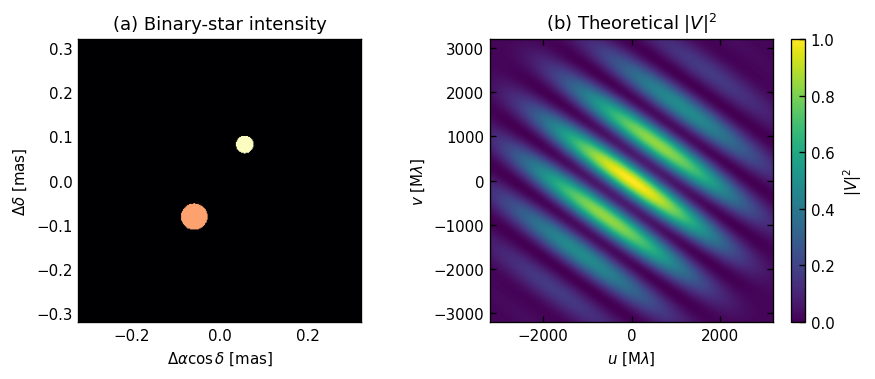

In [3]:
def sky_image(source_case, source, theta_mas):
    # 在显示网格上生成归一化天体真值；解析可见度不依赖此像素化。
    yy, xx = np.meshgrid(theta_mas, theta_mas, indexing="ij")
    image = np.zeros_like(xx)
    if source_case == "binary":
        angle = np.deg2rad(source.position_angle_deg)
        dx = 0.5 * source.separation_mas * np.sin(angle)
        dy = 0.5 * source.separation_mas * np.cos(angle)
        first = (xx + dx) ** 2 + (yy + dy) ** 2 <= (source.primary_diameter_mas / 2) ** 2
        second = (xx - dx) ** 2 + (yy - dy) ** 2 <= (source.secondary_diameter_mas / 2) ** 2
        image[first] = 1.0 / max(first.sum(), 1)
        image[second] += source.flux_ratio_secondary_to_primary / max(second.sum(), 1)
    elif source_case == "ellipse":
        angle = np.deg2rad(source.position_angle_deg)
        major = xx * np.sin(angle) + yy * np.cos(angle)
        minor = xx * np.cos(angle) - yy * np.sin(angle)
        mask = (major / (source.major_diameter_mas / 2)) ** 2 + (minor / (source.minor_diameter_mas / 2)) ** 2 <= 1
        image[mask] = 1.0
    elif source_case == "transit":
        star = xx**2 + yy**2 <= (source.stellar_diameter_mas / 2) ** 2
        planet = ((xx - source.planet_east_offset_mas) ** 2
                  + (yy - source.planet_north_offset_mas) ** 2
                  <= (source.planet_diameter_mas / 2) ** 2)
        image[star & ~planet] = 1.0
    else:
        raise ValueError(source_case)
    return image / image.sum()


def power_grid(source_case, source, limit_mlambda, points=301):
    spatial = np.linspace(-limit_mlambda, limit_mlambda, points) * 1e6
    vv, uu = np.meshgrid(spatial, spatial, indexing="ij")
    power = np.abs(source_visibility(uu, vv, source, source_case)) ** 2
    return spatial / 1e6, power


theta_display = np.linspace(-0.32, 0.32, 321)
binary_sky = sky_image("binary", reference_source, theta_display)
uvw_6h = generate_uvw(layout, reference_observation, instrument)
uv_limit = 1.05 * np.hypot(uvw_6h.u_lambda, uvw_6h.v_lambda).max() / 1e6
uv_axis, binary_power = power_grid("binary", reference_source, uv_limit)

fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.05), constrained_layout=True)
extent_sky = [theta_display[0], theta_display[-1], theta_display[0], theta_display[-1]]
axes[0].imshow(binary_sky, origin="lower", extent=extent_sky, cmap="magma")
axes[0].set(xlabel=r"$\Delta\alpha\cos\delta$ [mas]", ylabel=r"$\Delta\delta$ [mas]", title="(a) Binary-star intensity")
power_artist = axes[1].imshow(binary_power, origin="lower",
    extent=[uv_axis[0], uv_axis[-1], uv_axis[0], uv_axis[-1]],
    cmap="viridis", vmin=0, vmax=1)
axes[1].set(xlabel=r"$u$ [M$\lambda$]", ylabel=r"$v$ [M$\lambda$]", title=r"(b) Theoretical $|V|^2$")
fig.colorbar(power_artist, ax=axes[1], label=r"$|V|^2$")
for axis in axes:
    axis.set_aspect("equal")
fig.savefig(FIGURE_DIR / "10_source_and_theoretical_uv.png", bbox_inches="tight")
plt.show()

## 4. 32 台望远镜的分时段 UV 覆盖

望远镜位置给出物理基线，源方向与地球自转把基线投影到 ​(u,v,w)​。下面比较瞬时20分钟段、2小时和6小时的覆盖。图中同时绘制 ​((u,v))​ 与 ​((-u,-v))​，但负基线不是额外的独立测量。

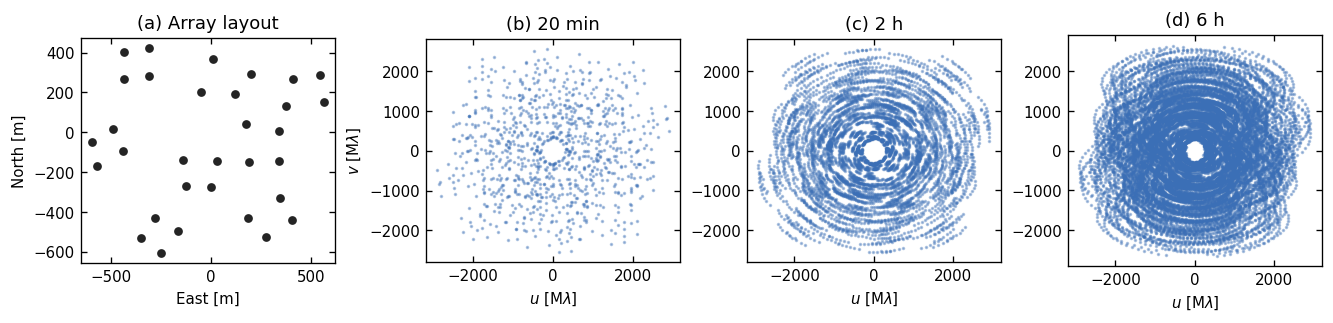

,Duration,Independent measurements,Displayed points including conjugates,Maximum projected baseline [m]
0,20 min,496,992,1214.69
1,2 h,2976,5952,1219.19
2,6 h,8928,17856,1219.19


In [4]:
coverage_observations = {
    "20 min": Observation(hours_per_night=1/3, segment_s=1200.0),
    "2 h": Observation(hours_per_night=2.0, segment_s=1200.0),
    "6 h": reference_observation,
}
coverage = {label: generate_uvw(layout, obs, instrument)
            for label, obs in coverage_observations.items()}

fig, axes = plt.subplots(1, 4, figsize=(11.0, 2.75), constrained_layout=True)
axes[0].scatter(layout.east_m, layout.north_m, s=18, c=INK)
axes[0].set(xlabel="East [m]", ylabel="North [m]", title="(a) Array layout")
axes[0].set_aspect("equal")
for panel, (label, frame) in enumerate(coverage.items(), start=1):
    x = frame.u_lambda.to_numpy() / 1e6
    y = frame.v_lambda.to_numpy() / 1e6
    axes[panel].scatter(np.r_[x, -x], np.r_[y, -y], s=1.2, c=BLUE, alpha=0.38, rasterized=True)
    axes[panel].set(xlabel=r"$u$ [M$\lambda$]", title=f"({chr(97+panel)}) {label}")
    axes[panel].set_aspect("equal")
    if panel == 1:
        axes[panel].set_ylabel(r"$v$ [M$\lambda$]")
fig.savefig(FIGURE_DIR / "11_array_and_uv_coverage.png", bbox_inches="tight")
plt.show()

coverage_table = pd.DataFrame([
    {"Duration": label, "Independent measurements": len(frame),
     "Displayed points including conjugates": 2 * len(frame),
     "Maximum projected baseline [m]": frame.projected_baseline_m.max()}
    for label, frame in coverage.items()
])
display(coverage_table.round(2))

## 5. 用完整短波形标定 GLS 测量

每台望远镜的单像素数据由恒星光电子、独立NSB、光学到达时间核、实测SPE和微单元恢复共同生成。对两条ADC波形计算多个时间延迟处的互相关向量，再由已知注入和零相关样本标定峰模板及噪声协方差。模板训练时增强相关对数仅用于降低Monte Carlo成本，最终长曝光协方差仍按物理零信号记录确定。

In [5]:
# 暗源需要更高的训练注入倍率；它不会改变最终物理SNR。
calibration_settings = {
    2.0: dict(hbt_pair_rate_scale=10_000.0, seed=SEED + 2),
    3.0: dict(hbt_pair_rate_scale=30_000.0, seed=SEED + 3),
    4.0: dict(hbt_pair_rate_scale=100_000.0, seed=SEED + 4),
    5.0: dict(hbt_pair_rate_scale=300_000.0, seed=SEED + 5),
}
calibrations = {}
calibration_diagnostics = {}
for magnitude, settings in calibration_settings.items():
    calibration, diagnostics = simulate_waveform_gls_calibration(
        instrument, source_ab_magnitude=magnitude,
        null_records=1024, signal_records=256,
        block_duration_ns=20_000.0, max_lag_ns=200.0,
        **settings)
    calibrations[magnitude] = calibration
    calibration_diagnostics[magnitude] = diagnostics

calibration_table = []
for magnitude, calibration in calibrations.items():
    _, sigma_20min = waveform_gls_weights(calibration, 1200.0)
    diagnostics = calibration_diagnostics[magnitude]
    calibration_table.append({
        "m_AB": magnitude,
        "Detected star rate [MHz]": calibration.star_rate_hz / 1e6,
        "Physical HBT pair rate [s-1]": diagnostics["physical_hbt_pair_rate_hz"],
        "Response closure": diagnostics["validation_response_closure"],
        "sigma_P (20 min)": sigma_20min,
    })
calibration_table = pd.DataFrame(calibration_table)
display(calibration_table.round(4))

,m_AB,Detected star rate [MHz],Physical HBT pair rate [s-1],Response closure,sigma_P (20 min)
0,2.0,201.5476,4563.5881,1.0013,0.1742
1,3.0,80.2375,723.2800,0.9725,0.6387
2,4.0,31.9431,114.6321,0.9860,2.7135
3,5.0,12.7168,18.1680,1.0323,13.5773


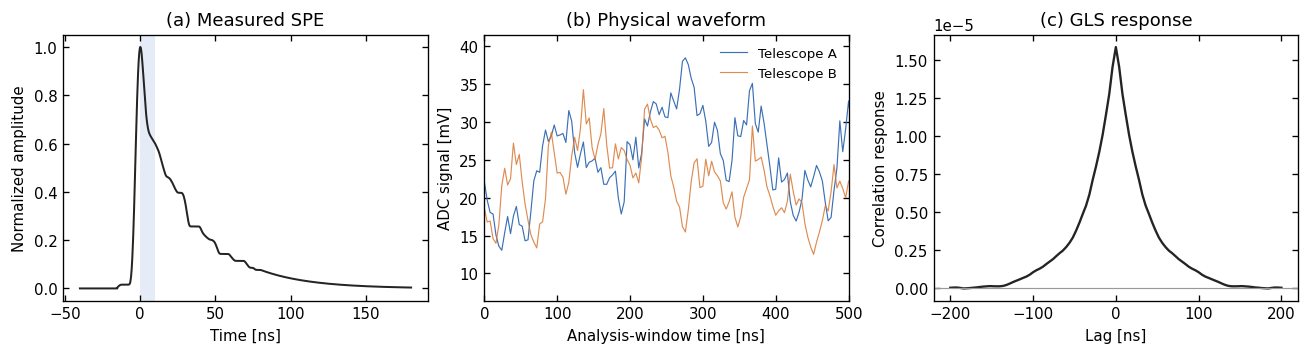

2 us有效窗内期望的物理HBT相关对：0.0091
20 us标定块外推到20 min时的 sigma_P：0.1742


In [6]:
reference_calibration = calibrations[2.0]
reference_diagnostics = calibration_diagnostics[2.0]
spe_time, spe_voltage = load_measured_spe_template(instrument.spe_template_path)
timing = load_optical_timing_mixture(instrument.optical_timing_kernel_path)
padding_ns = reference_diagnostics["padding_ns"]

# 2微秒物理记录用于显示真实波形；padding只供卷积，相关只使用有效窗。
rng = np.random.default_rng(SEED + 50)
physical_hits, physical_meta = simulate_hbt_primary_pe(
    rng, 2_000.0, reference_calibration.star_rate_hz,
    reference_calibration.background_rate_hz, 1.0, instrument,
    optical_timing_mixture=timing, padding_ns=padding_ns)
waveforms = []
for telescope_id in (0, 1):
    times = physical_hits.loc[physical_hits.telescope_id == telescope_id, "time_ns"].to_numpy()
    waveforms.append(render_pe_waveform(
        rng, times, 2_000.0, instrument,
        template=(spe_time, spe_voltage))["adc_mv"])
sample_time = np.arange(len(waveforms[0])) * instrument.sample_width_ns
lags, physical_correlation = waveform_cross_correlation(
    waveforms[0], waveforms[1], instrument.sample_width_ns, 200.0)
_, sigma_block = waveform_gls_weights(reference_calibration, reference_calibration.block_duration_s)

fig, axes = plt.subplots(1, 3, figsize=(10.8, 2.85), constrained_layout=True)
axes[0].plot(spe_time, spe_voltage / np.max(np.abs(spe_voltage)), color=INK, lw=1.2)
axes[0].axvspan(0, 10, color=LIGHT, alpha=0.45, lw=0)
axes[0].set(xlabel="Time [ns]", ylabel="Normalized amplitude", title="(a) Measured SPE")
axes[1].plot(sample_time, waveforms[0], color=BLUE, lw=0.7, label="Telescope A")
axes[1].plot(sample_time, waveforms[1], color=ORANGE, lw=0.7, alpha=0.85, label="Telescope B")
axes[1].set_xlim(0, 500)
axes[1].set(xlabel="Analysis-window time [ns]", ylabel="ADC signal [mV]", title="(b) Physical waveform")
axes[1].legend(loc="upper right")
peak = reference_calibration.peak_per_visibility2
axes[2].plot(reference_calibration.lags_ns, peak, color=INK, lw=1.4, label=r"Response $k(\tau)$")
axes[2].axhline(0, color="0.6", lw=0.7)
axes[2].set(xlabel="Lag [ns]", ylabel="Correlation response", title="(c) GLS response")
fig.savefig(FIGURE_DIR / "12_waveform_gls_measurement.png", bbox_inches="tight")
plt.show()

print(f"2 us有效窗内期望的物理HBT相关对：{physical_meta['expected_hbt_pairs_in_analysis_window']:.4f}")
print(f"20 us标定块外推到20 min时的 sigma_P：{waveform_gls_weights(reference_calibration, 1200.0)[1]:.4f}")

## 6. 从波形统计量得到实际模拟 UV 数据

以下6小时数据包含18个20分钟时间段和496条基线。每个点的 ​\(\hat P\)​ 是从模拟的完整相关向量经同一GLS估计器得到；图中没有把负值或大于1的值裁剪成物理范围。颜色显示范围只为避免少量极端噪声点压缩主体结构。
这些相关向量按短波形标定的均值和协方差抽样，并非逐采样模拟了完整6小时ADC。

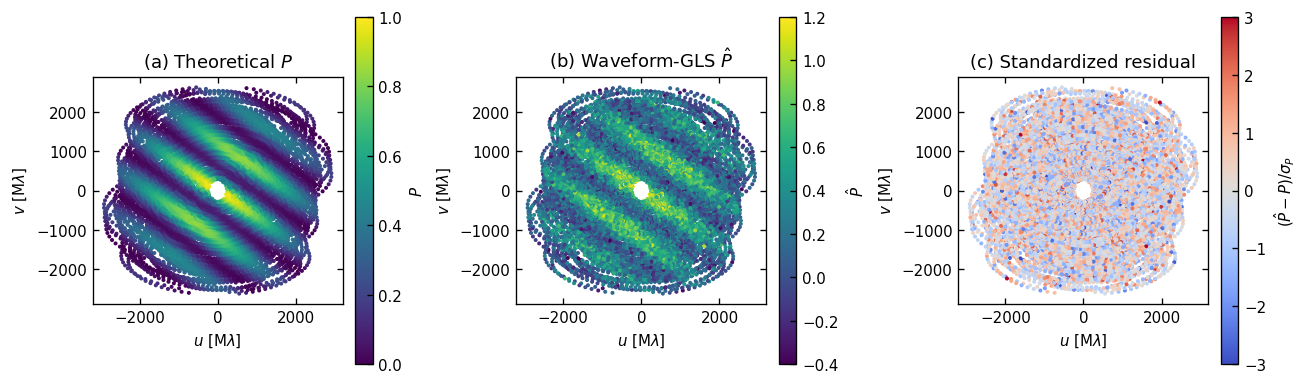

,Measurements,sigma_P per 20-min point,Residual mean,Residual standard deviation,"Raw estimates outside [0,1]"
0,8928,0.1742,-0.0087,1.0015,1300


In [7]:
reconstruction_kwargs = dict(
    grid_size=40, fov_mas=0.70, support_radius_mas=0.32,
    starts=3, max_iter=1600, smoothness="cv", likelihood="gaussian",
    parameterization="flux", optimizer_ftol=1e-12, huber_delta=2.5, peak_minimum_separation_mas=0.10)

reference_pipeline = run_sii_pipeline(
    layout, reference_source, reference_observation, instrument,
    seed=SEED + 100, estimator="waveform_gls",
    waveform_calibration=reference_calibration,
    reconstruction_kwargs=reconstruction_kwargs)
measured_uv = reference_pipeline.measurements

def symmetric_uv_scatter(axis, frame, values, cmap, norm, label):
    u = frame.u_lambda.to_numpy() / 1e6
    v = frame.v_lambda.to_numpy() / 1e6
    values = np.asarray(values)
    artist = axis.scatter(np.r_[u, -u], np.r_[v, -v], c=np.r_[values, values],
                          s=2.0, cmap=cmap, norm=norm, rasterized=True)
    axis.set(xlabel=r"$u$ [M$\lambda$]", ylabel=r"$v$ [M$\lambda$]")
    axis.set_aspect("equal")
    return artist

truth = measured_uv.visibility2_true.to_numpy()
measurement = measured_uv.visibility2_measured.to_numpy()
sigma = measured_uv.sigma_visibility2.to_numpy()
standardized_residual = (measurement - truth) / sigma

fig, axes = plt.subplots(1, 3, figsize=(10.8, 3.1), constrained_layout=True)
artists = [
    symmetric_uv_scatter(axes[0], measured_uv, truth, "viridis", Normalize(0, 1), r"$P$"),
    symmetric_uv_scatter(axes[1], measured_uv, measurement, "viridis", Normalize(-0.4, 1.2), r"$\hat P$"),
    symmetric_uv_scatter(axes[2], measured_uv, standardized_residual, "coolwarm", TwoSlopeNorm(0, -3, 3), "Residual"),
]
for axis, title, artist, label in zip(
        axes, [r"(a) Theoretical $P$", r"(b) Waveform-GLS $\hat P$", "(c) Standardized residual"],
        artists, [r"$P$", r"$\hat P$", r"$(\hat P-P)/\sigma_P$"]):
    axis.set_title(title)
    fig.colorbar(artist, ax=axis, label=label)
fig.savefig(FIGURE_DIR / "13_waveform_gls_observed_uv.png", bbox_inches="tight")
plt.show()

uv_diagnostics = pd.DataFrame([{
    "Measurements": len(measured_uv),
    "sigma_P per 20-min point": float(np.median(sigma)),
    "Residual mean": float(np.mean(standardized_residual)),
    "Residual standard deviation": float(np.std(standardized_residual, ddof=1)),
    "Raw estimates outside [0,1]": int(np.sum((measurement < 0) | (measurement > 1))),
}])
display(uv_diagnostics.round(4))

## 7. 不同观测时间的重建

重建器只接收带噪的 ​\(\hat P\)​、不确定度和UV坐标，不读取天体真值。显示时允许平移和180度镜像对齐，因为这两项本来就不能由可见度模平方唯一确定。下面是一组固定随机种子的代表性 realization，不等同于多次试验得到的检出概率。

更新：主重建现在使用绝对高斯似然，不截断逆方差、不加入人为零基线测量。
模型预测按测量的时间子采样和UV格逆方差进行相同平均。
平滑强度在固定候选集上以80%训练、20%留出数据选择；真图只用于事后评估。
候选集、留出分割和初值固定可复现；这不是最终独立测试，仍需下面的重复实验。

主结果和新旧对照将迭代上限统一提高至1600；仍逐项报告是否达到停止准则，不能只凭迭代预算宣称收敛。
当前主结果改用直接非负像素归一化，默认相对函数容差为1e-12。物理目标和先验定义不变；softmax仅保留作数值对照，见附录E。
本次2 h选中解未在1600次内满足停止准则；保留该状态，不把图像外观当作收敛证明。

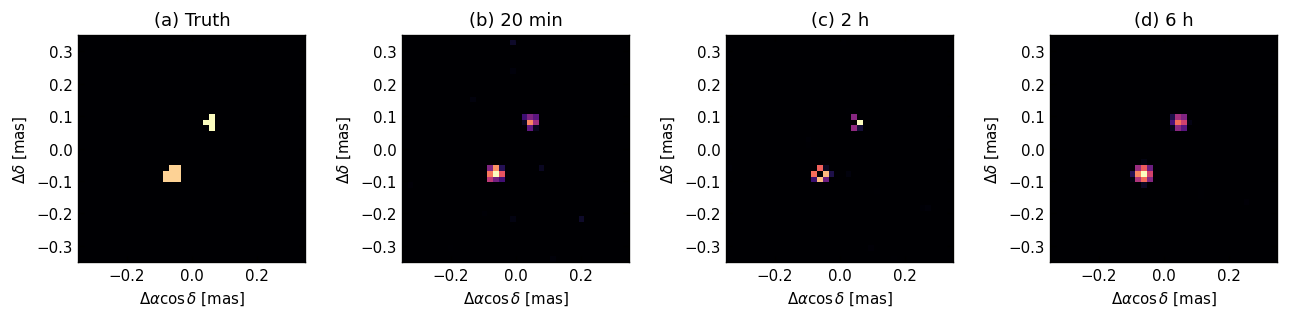

,Duration,UV measurements,Weighted visibility RMSE,Truth-image correlation,Recovered separation [mas]
0,20 min,496,0.1477,0.8169,0.1941
1,2 h,2976,0.0879,0.6870,0.2191
2,6 h,8928,0.0576,0.8695,0.1941


In [8]:
def align_for_display(image, truth_image):
    # 只为验证显示选择平移和180度镜像；不参与优化。
    best = None
    for candidate in (image, image[::-1, ::-1]):
        corr = np.fft.ifft2(np.fft.fft2(truth_image) * np.conj(np.fft.fft2(candidate))).real
        iy, ix = np.unravel_index(np.argmax(corr), corr.shape)
        sy = iy if iy <= image.shape[0] // 2 else iy - image.shape[0]
        sx = ix if ix <= image.shape[1] // 2 else ix - image.shape[1]
        aligned = np.roll(candidate, (sy, sx), axis=(0, 1))
        coefficient = np.corrcoef(aligned.ravel(), truth_image.ravel())[0, 1]
        if best is None or coefficient > best[0]:
            best = coefficient, aligned
    return best


# 从同一6小时 realization 中逐步增加中心时段，避免把随机差异误当时间趋势。
segment_order = (measured_uv[["segment", "hour_angle_h"]].drop_duplicates()
                 .assign(abs_hour_angle=lambda frame: frame.hour_angle_h.abs())
                 .sort_values(["abs_hour_angle", "hour_angle_h"]))
selected_segment_counts = {"20 min": 1, "2 h": 6, "6 h": 18}
time_measurements = {}
time_reconstructions = {}
for label, count in selected_segment_counts.items():
    segment_ids = segment_order.head(count).segment.to_numpy()
    subset = measured_uv.loc[measured_uv.segment.isin(segment_ids)].copy()
    time_measurements[label] = subset
    time_reconstructions[label] = reconstruct_uv(
        subset, seed=SEED + 120 + count, **reconstruction_kwargs)

theta_reco = reference_pipeline.reconstruction.theta_mas
truth_reco = sky_image("binary", reference_source, theta_reco)
extent_reco = [theta_reco[0], theta_reco[-1], theta_reco[0], theta_reco[-1]]

fig, axes = plt.subplots(1, 4, figsize=(10.8, 2.55), constrained_layout=True)
axes[0].imshow(truth_reco, origin="lower", extent=extent_reco, cmap="magma")
axes[0].set_title("(a) Truth")
time_rows = []
for panel, label in enumerate(["20 min", "2 h", "6 h"], start=1):
    reconstruction = time_reconstructions[label]
    correlation, aligned = align_for_display(reconstruction.image, truth_reco)
    axes[panel].imshow(aligned, origin="lower", extent=extent_reco, cmap="magma")
    axes[panel].set_title(f"({chr(97+panel)}) {label}")
    metrics = reconstruction.metrics
    time_rows.append({
        "Duration": label, "UV measurements": len(time_measurements[label]),
        "Weighted visibility RMSE": metrics["weighted_fit_rmse"],
        "Truth-image correlation": correlation,
        "Recovered separation [mas]": metrics.get("two_peak_separation_mas", np.nan),
    })
for axis in axes:
    axis.set(xlabel=r"$\Delta\alpha\cos\delta$ [mas]", ylabel=r"$\Delta\delta$ [mas]")
    axis.set_aspect("equal")
fig.savefig(FIGURE_DIR / "14_reconstruction_vs_time.png", bbox_inches="tight")
plt.show()
display(pd.DataFrame(time_rows).round(4))

### 7.1 不同观测时间对应的实际 UV 平面

三幅图使用相同的颜色范围，并且数据严格嵌套。20分钟只有一个中心时间段的496条基线；2小时和6小时依次加入更多时间段。这里显示的是波形GLS直接给出的带噪 \(\hat P\)，不是理论真值。

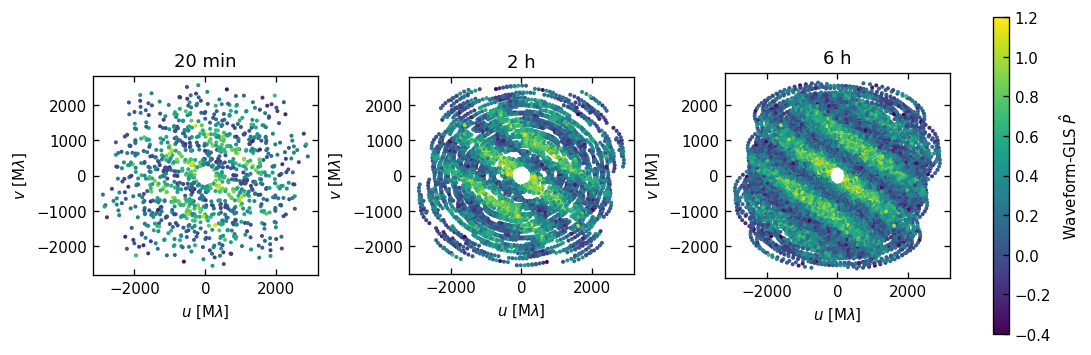

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(9.0, 2.85), constrained_layout=True)
time_uv_artist = None
for axis, label in zip(axes, ["20 min", "2 h", "6 h"]):
    frame = time_measurements[label]
    time_uv_artist = symmetric_uv_scatter(
        axis, frame, frame.visibility2_measured,
        "viridis", Normalize(-0.4, 1.2), r"$\hat P$")
    axis.set_title(label)
fig.colorbar(time_uv_artist, ax=axes, label=r"Waveform-GLS $\hat P$")
fig.savefig(FIGURE_DIR / "17_observed_uv_vs_time.png", bbox_inches="tight")
plt.show()

## 8. 较暗双星随观测时间的重建

为检验亮源20分钟结果是否过于乐观，本节把总亮度降为 \(m_{\rm AB}=4\)，并使用该星等独立标定的波形响应。20分钟、2小时和6小时仍取自同一个6小时 realization。它用于展示过渡行为，不替代多随机种子检出概率。

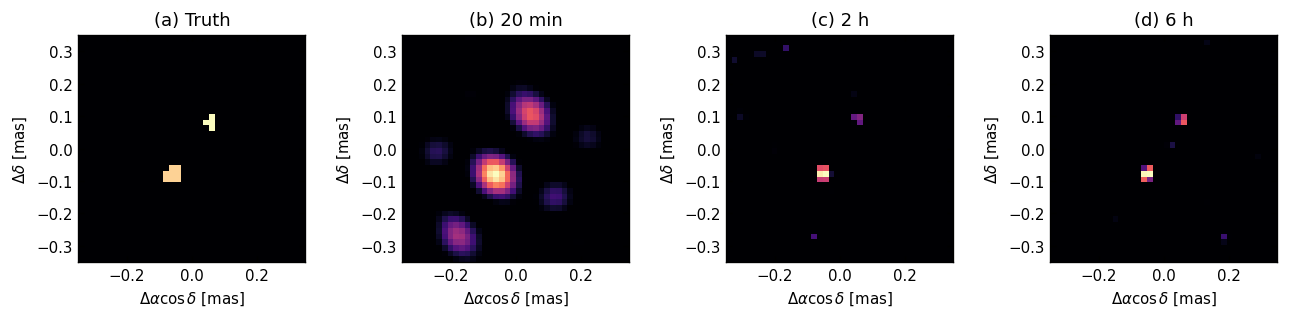

,Duration,UV measurements,Weighted visibility RMSE,Truth-image correlation,Recovered separation [mas]
0,20 min,496,2.5445,0.5108,0.2093
1,2 h,2976,1.3993,0.7277,0.2093
2,6 h,8928,0.9003,0.7803,0.1941


In [10]:
faint_source = replace(reference_source, ab_magnitude=4.0)
faint_pipeline_6h = run_sii_pipeline(
    layout, faint_source, reference_observation, instrument,
    seed=SEED + 204, estimator="waveform_gls",
    waveform_calibration=calibrations[4.0],
    reconstruction_kwargs=reconstruction_kwargs)

faint_time_measurements = {}
faint_time_reconstructions = {}
for label, count in selected_segment_counts.items():
    segment_ids = segment_order.head(count).segment.to_numpy()
    subset = faint_pipeline_6h.measurements.loc[
        faint_pipeline_6h.measurements.segment.isin(segment_ids)].copy()
    faint_time_measurements[label] = subset
    faint_time_reconstructions[label] = reconstruct_uv(
        subset, seed=SEED + 520 + count, **reconstruction_kwargs)

fig, axes = plt.subplots(1, 4, figsize=(10.8, 2.55), constrained_layout=True)
axes[0].imshow(truth_reco, origin="lower", extent=extent_reco, cmap="magma")
axes[0].set_title("(a) Truth")
faint_time_rows = []
for panel, label in enumerate(["20 min", "2 h", "6 h"], start=1):
    reconstruction = faint_time_reconstructions[label]
    correlation, aligned = align_for_display(reconstruction.image, truth_reco)
    axes[panel].imshow(aligned, origin="lower", extent=extent_reco, cmap="magma")
    axes[panel].set_title(f"({chr(97 + panel)}) {label}")
    metrics = reconstruction.metrics
    faint_time_rows.append({
        "Duration": label,
        "UV measurements": len(faint_time_measurements[label]),
        "Weighted visibility RMSE": metrics["weighted_fit_rmse"],
        "Truth-image correlation": correlation,
        "Recovered separation [mas]": metrics.get("two_peak_separation_mas", np.nan),
    })
for axis in axes:
    axis.set(xlabel=r"$\Delta\alpha\cos\delta$ [mas]",
             ylabel=r"$\Delta\delta$ [mas]")
    axis.set_aspect("equal")
fig.savefig(FIGURE_DIR / "18_faint_m4_reconstruction_vs_time.png", bbox_inches="tight")
plt.show()
display(pd.DataFrame(faint_time_rows).round(4))

## 9. 不同星等的重建

星等改变恒星光子率，也会改变波形相关峰相对于NSB散粒噪声的强度。因此每个星等都独立生成短波形标定，而不是复用2等星的不确定度。这里比较2至5等星在同一6小时几何覆盖下的一次模拟结果。
附带BIC表属于另一个有模型拟合诊断，不参与像素重建；它固定分量直径，双星拟合从设定场景参数初始化，因此不能代替盲搜成功率或极限星等检验。

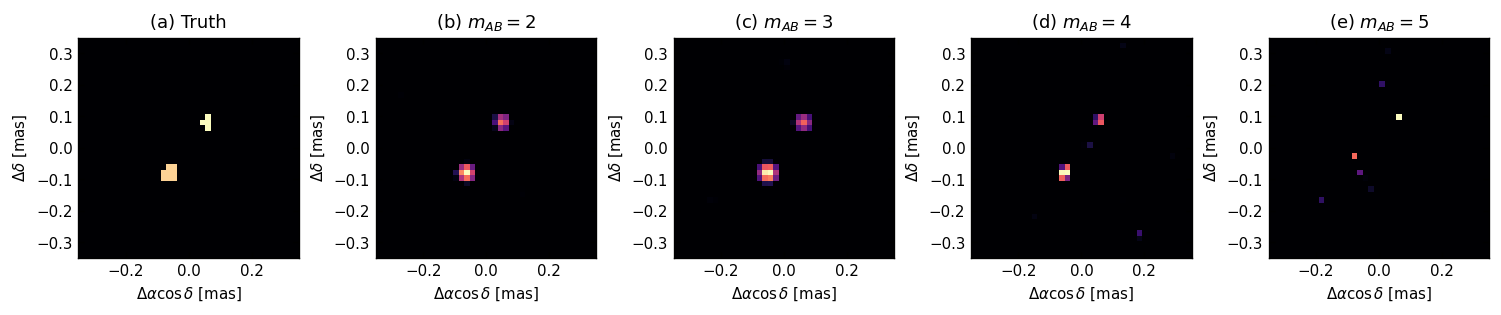

,m_AB,sigma_P per 20-min point,Weighted visibility RMSE,Truth-image correlation,Recovered separation [mas],Delta BIC (single - binary)
0,2.0,0.1742,0.0576,0.8699,0.1941,28006.8965
1,3.0,0.6387,0.2203,0.8586,0.1941,1839.6227
2,4.0,2.7135,0.9003,0.7803,0.1941,100.3468
3,5.0,13.5773,4.4121,0.3040,0.1908,-5.7670


In [11]:
magnitude_pipelines = {2.0: reference_pipeline, 4.0: faint_pipeline_6h}
for magnitude in (3.0, 5.0):
    source = replace(reference_source, ab_magnitude=magnitude)
    magnitude_pipelines[magnitude] = run_sii_pipeline(
        layout, source, reference_observation, instrument,
        seed=SEED + 200 + int(magnitude), estimator="waveform_gls",
        waveform_calibration=calibrations[magnitude],
        reconstruction_kwargs=reconstruction_kwargs)

fig, axes = plt.subplots(1, 5, figsize=(12.4, 2.45), constrained_layout=True)
axes[0].imshow(truth_reco, origin="lower", extent=extent_reco, cmap="magma")
axes[0].set_title("(a) Truth")
magnitude_rows = []
for panel, magnitude in enumerate((2.0, 3.0, 4.0, 5.0), start=1):
    pipeline = magnitude_pipelines[magnitude]
    correlation, aligned = align_for_display(pipeline.reconstruction.image, truth_reco)
    axes[panel].imshow(aligned, origin="lower", extent=extent_reco, cmap="magma")
    axes[panel].set_title(f"({chr(97+panel)}) $m_{{AB}}={magnitude:.0f}$")
    metrics = pipeline.reconstruction.metrics
    magnitude_rows.append({
        "m_AB": magnitude,
        "sigma_P per 20-min point": pipeline.metadata["sigma_visibility2_total"],
        "Weighted visibility RMSE": metrics["weighted_fit_rmse"],
        "Truth-image correlation": correlation,
        "Recovered separation [mas]": metrics.get("two_peak_separation_mas", np.nan),
    })

# 用参数化双星和单星圆盘的BIC差判断双峰是否由数据支持。
def binary_vs_single_delta_bic(pipeline, magnitude):
    frame = pipeline.measurements
    observed = frame.visibility2_measured.to_numpy()
    sigma = frame.sigma_visibility2.to_numpy()
    observation = reference_observation

    def chi2_binary(parameters):
        separation, position_angle, flux_ratio = parameters
        trial = replace(reference_source, ab_magnitude=magnitude,
                        separation_mas=separation,
                        position_angle_deg=position_angle,
                        flux_ratio_secondary_to_primary=flux_ratio)
        prediction = segment_averaged_visibility2(
            frame, trial, observation, instrument, "binary")
        return np.sum(((observed - prediction) / sigma) ** 2)

    def chi2_single(parameters):
        trial = replace(reference_source, ab_magnitude=magnitude,
                        primary_diameter_mas=float(parameters[0]))
        prediction = segment_averaged_visibility2(
            frame, trial, observation, instrument, "single_disk")
        return np.sum(((observed - prediction) / sigma) ** 2)

    binary_fit = minimize(
        chi2_binary, [0.20, 35.0, 0.55], method="L-BFGS-B",
        bounds=[(0.02, 0.40), (0.0, 180.0), (0.05, 1.0)])
    single_fit = minimize(
        chi2_single, [0.10], method="L-BFGS-B", bounds=[(0.01, 0.50)])
    n = len(frame)
    bic_binary = binary_fit.fun + 3 * np.log(n)
    bic_single = single_fit.fun + np.log(n)
    return bic_single - bic_binary

for row in magnitude_rows:
    row["Delta BIC (single - binary)"] = binary_vs_single_delta_bic(
        magnitude_pipelines[row["m_AB"]], row["m_AB"])
for axis in axes:
    axis.set(xlabel=r"$\Delta\alpha\cos\delta$ [mas]", ylabel=r"$\Delta\delta$ [mas]")
    axis.set_aspect("equal")
fig.savefig(FIGURE_DIR / "15_reconstruction_vs_magnitude.png", bbox_inches="tight")
plt.show()
display(pd.DataFrame(magnitude_rows).round(4))

### 9.1 不同星等对应的实际 UV 显著性平面

原始 \(\hat P\) 的噪声尺度随星等跨越近两个数量级，直接使用同一线性色标会隐藏亮源结构。下面统一显示每个测量的 \(\hat P/\sigma_P\)，色标范围完全相同；超过范围的点只在显示中饱和，数据没有裁剪。

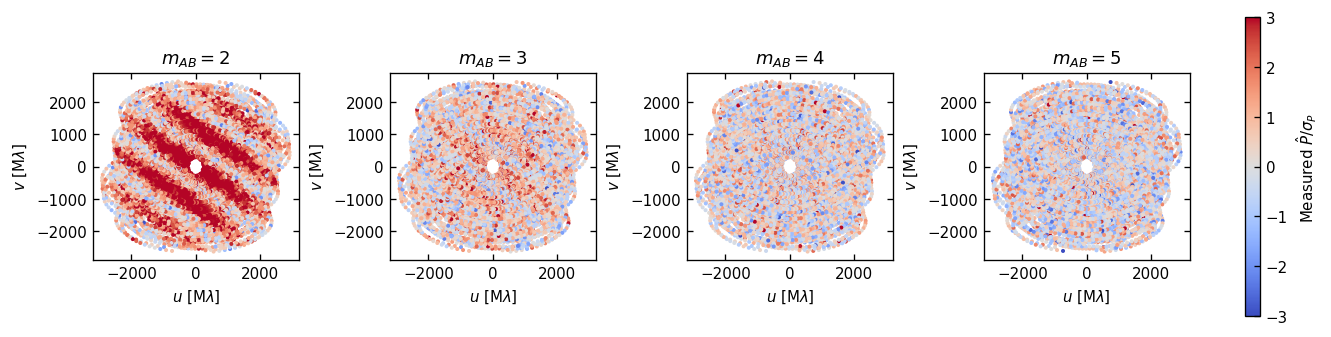

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(11.0, 2.7), constrained_layout=True)
magnitude_uv_artist = None
for axis, magnitude in zip(axes, [2.0, 3.0, 4.0, 5.0]):
    frame = magnitude_pipelines[magnitude].measurements
    significance = frame.visibility2_measured / frame.sigma_visibility2
    magnitude_uv_artist = symmetric_uv_scatter(
        axis, frame, significance, "coolwarm",
        TwoSlopeNorm(vcenter=0.0, vmin=-3.0, vmax=3.0),
        r"$\hat P/\sigma_P$")
    axis.set_title(rf"$m_{{AB}}={magnitude:.0f}$")
fig.colorbar(magnitude_uv_artist, ax=axes, label=r"Measured $\hat P/\sigma_P$")
fig.savefig(FIGURE_DIR / "19_observed_uv_vs_magnitude.png", bbox_inches="tight")
plt.show()

## 10. 双星、均匀椭圆与凌日模型

三种源使用相同的总AB星等、阵列、单夜6小时观测和波形标定。每行依次给出天体真值、连续理论 ​\(|V|^2\)​ 和从带噪测量得到的无模型重建。凌日模型采用完全位于均匀恒星盘内的不透明圆盘，是方法检验模型，不包含临边昏暗。
本次三组6 h基准均达到停止准则，但凌日暗区未被忠实恢复。天图面板分别自动设色标，仅比较形态；共色标对照见附录D、E。

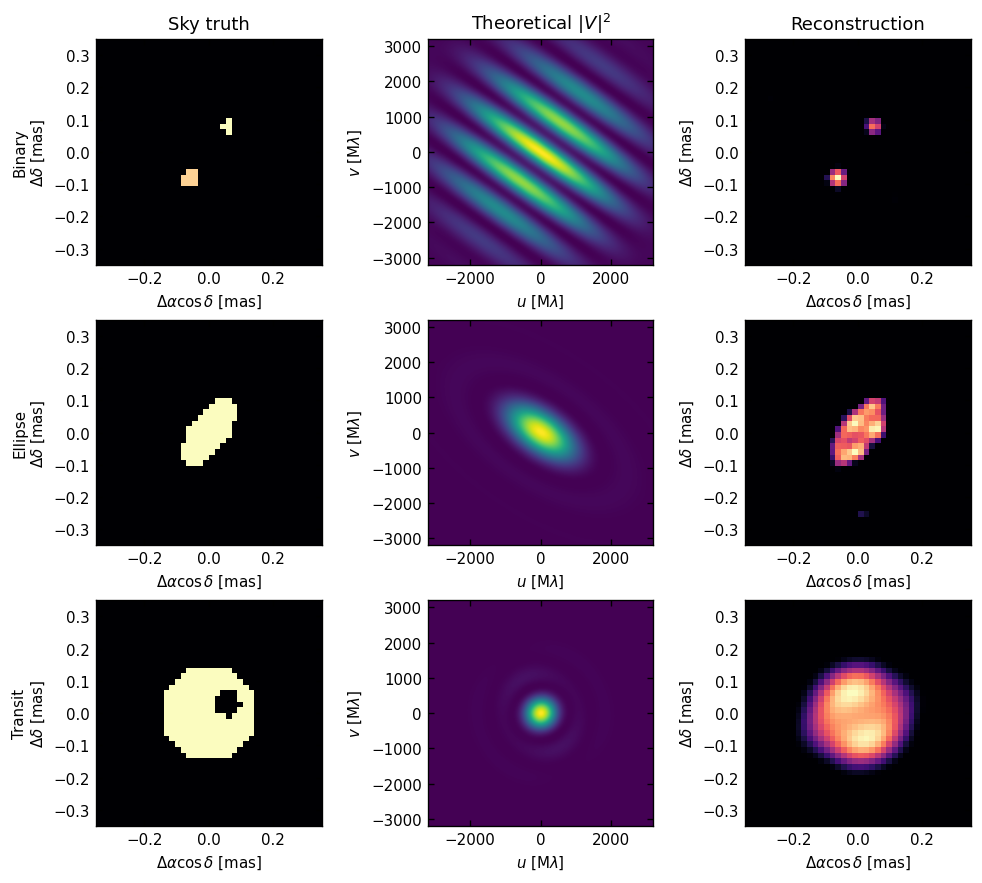

,Model,Weighted visibility RMSE,Truth-image correlation,Optimizer success
0,Binary,0.0576,0.8699,True
1,Ellipse,0.0578,0.9401,True
2,Transit,0.0600,0.8866,True


In [13]:
model_sources = {
    "Binary": ("binary", reference_source),
    "Ellipse": ("ellipse", EllipseSource(ab_magnitude=2.0)),
    "Transit": ("transit", TransitSource(ab_magnitude=2.0)),
}
model_pipelines = {"Binary": reference_pipeline}
for index, (name, (source_case, source)) in enumerate(model_sources.items()):
    if name == "Binary":
        continue
    model_pipelines[name] = run_sii_pipeline(
        layout, source, reference_observation, instrument,
        seed=SEED + 300 + index, estimator="waveform_gls",
        waveform_calibration=reference_calibration, source_case=source_case,
        reconstruction_kwargs=reconstruction_kwargs)

fig, axes = plt.subplots(3, 3, figsize=(8.2, 7.25), constrained_layout=True)
model_rows = []
for row, (name, (source_case, source)) in enumerate(model_sources.items()):
    truth_image = sky_image(source_case, source, theta_reco)
    uv_axis_model, theory_power = power_grid(source_case, source, uv_limit, points=241)
    pipeline = model_pipelines[name]
    correlation, aligned = align_for_display(pipeline.reconstruction.image, truth_image)
    axes[row, 0].imshow(truth_image, origin="lower", extent=extent_reco, cmap="magma")
    axes[row, 1].imshow(theory_power, origin="lower",
        extent=[uv_axis_model[0], uv_axis_model[-1], uv_axis_model[0], uv_axis_model[-1]],
        cmap="viridis", vmin=0, vmax=1)
    axes[row, 2].imshow(aligned, origin="lower", extent=extent_reco, cmap="magma")
    axes[row, 0].set_ylabel(f"{name}\n" + r"$\Delta\delta$ [mas]")
    model_rows.append({
        "Model": name,
        "Weighted visibility RMSE": pipeline.reconstruction.metrics["weighted_fit_rmse"],
        "Truth-image correlation": correlation,
        "Optimizer success": pipeline.reconstruction.metrics["optimizer_success"],
    })
for col, title in enumerate(["Sky truth", r"Theoretical $|V|^2$", "Reconstruction"]):
    axes[0, col].set_title(title)
for row in range(3):
    axes[row, 0].set_xlabel(r"$\Delta\alpha\cos\delta$ [mas]")
    axes[row, 1].set_xlabel(r"$u$ [M$\lambda$]")
    axes[row, 1].set_ylabel(r"$v$ [M$\lambda$]")
    axes[row, 2].set_xlabel(r"$\Delta\alpha\cos\delta$ [mas]")
    axes[row, 2].set_ylabel(r"$\Delta\delta$ [mas]")
    for col in range(3):
        axes[row, col].set_aspect("equal")
fig.savefig(FIGURE_DIR / "16_reconstruction_source_models.png", bbox_inches="tight")
plt.show()
display(pd.DataFrame(model_rows).round(4))

### 10.1 凌日模型的多夜累计观测

为区分统计噪声和无相位重建限制，下面固定每天相同的6小时UV轨迹，把1、10和100个独立夜晚逐次平均，对应总积分6、60和600小时。第一夜就是上图的凌日 realization；其余夜晚使用同一个波形GLS不确定度生成独立噪声。因此比较只研究积分时间，不包含长期增益漂移、时钟漂移或天气变化。重复相同小时角不会增加新的UV位置。
6/60/600 h选中解分别在205/415/826次迭代达到停止准则，但盘面仍不均匀，不能认定唯一行星暗区已恢复。

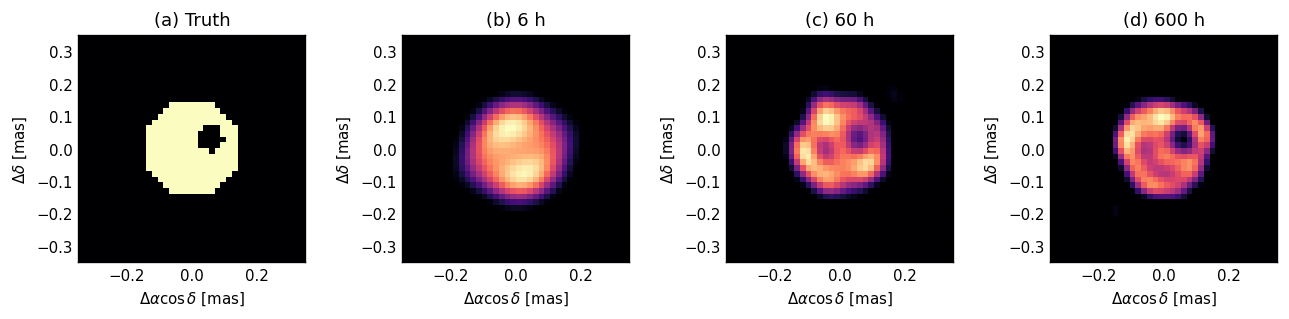

,Total integration,Nights,sigma_P per UV point,Weighted visibility RMSE,Truth-image correlation
0,6 h,1,0.1742,0.0600,0.8866
1,60 h,10,0.0551,0.0187,0.9248
2,600 h,100,0.0174,0.0058,0.9386


In [14]:
transit_source = model_sources["Transit"][1]
transit_truth = sky_image("transit", transit_source, theta_reco)
transit_one_night = model_pipelines["Transit"].measurements.copy()
transit_true_power = transit_one_night.visibility2_true.to_numpy()
transit_sigma_one_night = transit_one_night.sigma_visibility2.to_numpy()

# 第一夜沿用图16的实际 realization；后99夜是相互独立的同方差测量。
first_night_residual = (
    transit_one_night.visibility2_measured.to_numpy() - transit_true_power)
transit_rng = np.random.default_rng(SEED + 610)
additional_night_residuals = transit_rng.normal(
    0.0, transit_sigma_one_night, size=(99, len(transit_one_night)))
nightly_residuals = np.vstack([first_night_residual, additional_night_residuals])

transit_night_counts = {"6 h": 1, "60 h": 10, "600 h": 100}
transit_multinight_measurements = {}
transit_multinight_reconstructions = {}

fig, axes = plt.subplots(1, 4, figsize=(10.8, 2.55), constrained_layout=True)
axes[0].imshow(transit_truth, origin="lower", extent=extent_reco, cmap="magma")
axes[0].set_title("(a) Truth")
transit_multinight_rows = []

for panel, (label, nights) in enumerate(transit_night_counts.items(), start=1):
    frame = transit_one_night.copy()
    frame["visibility2_measured"] = (
        transit_true_power + nightly_residuals[:nights].mean(axis=0))
    frame["sigma_visibility2"] = transit_sigma_one_night / np.sqrt(nights)
    frame["baseline_integration_s"] = (
        transit_one_night.baseline_integration_s.to_numpy() * nights)
    reconstruction = (model_pipelines["Transit"].reconstruction if nights == 1
                      else reconstruct_uv(
                          frame, seed=SEED + 620 + nights,
                          **reconstruction_kwargs))
    correlation, aligned = align_for_display(reconstruction.image, transit_truth)
    transit_multinight_measurements[label] = frame
    transit_multinight_reconstructions[label] = reconstruction

    axes[panel].imshow(aligned, origin="lower", extent=extent_reco, cmap="magma")
    axes[panel].set_title(f"({chr(97 + panel)}) {label}")
    transit_multinight_rows.append({
        "Total integration": label,
        "Nights": nights,
        "sigma_P per UV point": np.median(frame.sigma_visibility2),
        "Weighted visibility RMSE": reconstruction.metrics["weighted_fit_rmse"],
        "Truth-image correlation": correlation,
    })

for axis in axes:
    axis.set(xlabel=r"$\Delta\alpha\cos\delta$ [mas]",
             ylabel=r"$\Delta\delta$ [mas]")
    axis.set_aspect("equal")
fig.savefig(FIGURE_DIR / "20_transit_reconstruction_vs_nights.png", bbox_inches="tight")
plt.show()
display(pd.DataFrame(transit_multinight_rows).round(4))

### 10.2 同一6小时观测：20 min、5 min与1 min积分分段

固定2等星、32台阵列、6小时窗口和仪器设置，只改变每个UV点的积分时间
$\Delta T$；这不是改变ADC的4 ns采样间隔。先用原波形GLS流程生成1 min测量，
再把同一基线上相邻5个或20个测量取平均。因此三种分段来自同一次观测，
不是三套独立随机实现，也没有额外增加光子。

对连续$n$个等长、独立的小段，有
$$\widehat P_{n}=\frac{1}{n}\sum_{a=1}^{n}\widehat P_a,\qquad
\sigma_{P,n}=\frac{\sqrt{\sum_{a=1}^{n}\sigma_{P,a}^{2}}}{n}.$$
这里$a$编号小段，$n$是每个大段包含的小段数。粗段的理论值同样取小段时间平均，
不能直接当成段中心的瞬时真值。1 min数据来自短波形标定的长曝光相关向量抽样，
不是连续6小时ADC数组。

三种分段覆盖相同的小时角范围，短分段只让已有轨迹更密，并降低时间平均模糊，
不会增加新的基线轨迹。重建均使用同一初值种子、平滑候选集和120 Mλ的UV合并网格；
表中同时报告原始测量数和实际合并后测量点数（不添加人为归一化点）。这项网格近似会限制细分段
收益，因此本图不是未经UV合并的极限性能测试。

这里固定凌日暗斑的位置，是静态遮挡图像测试；真实行星会移动，不能把本例直接
解释为真实6小时凌日或多夜不分相位叠加。图中真值只用于事后评价和配准，
不传入重建器。

In [15]:
# 一次细时间分段的观测，再按同一物理基线合并，保证统计预算一致。
cadence_minutes = (20, 5, 1)
cadence_cell_mlambda = 120.0
cadence_observation = replace(reference_observation, nights=1, segment_s=60.0)
cadence_fine_pipeline = run_sii_pipeline(
    layout, transit_source, cadence_observation, instrument,
    seed=SEED + 700, estimator="waveform_gls", source_case="transit",
    waveform_calibration=reference_calibration, do_reconstruction=False)
cadence_fine = cadence_fine_pipeline.measurements
cadence_measurements = {}
cadence_reconstructions = {}
cadence_aligned = {}
cadence_rows = []
cadence_truth = sky_image("transit", transit_source, theta_reco)
pair_columns = ["telescope_i_index", "telescope_j_index"]
reconstruction_columns = ["u_lambda", "v_lambda", "visibility2_measured", "sigma_visibility2", "uv_samples_u", "uv_samples_v"]

for minutes in cadence_minutes:
    observation = replace(cadence_observation, segment_s=60.0 * minutes)
    if minutes == 1:
        frame = cadence_fine.copy()
    else:
        work = cadence_fine.assign(
            segment=cadence_fine.segment // minutes,
            variance=cadence_fine.sigma_visibility2 ** 2)
        averaged = work.groupby(["segment"] + pair_columns, as_index=False).agg(
            visibility2_measured=("visibility2_measured", "mean"),
            visibility2_true=("visibility2_true", "mean"),
            variance=("variance", "sum"), fine_segments=("segment", "size"),
            uv_samples_u=("uv_samples_u", lambda rows: tuple(x for row in rows for x in row)),
            uv_samples_v=("uv_samples_v", lambda rows: tuple(x for row in rows for x in row)))
        assert (averaged.fine_segments == minutes).all()
        averaged["sigma_visibility2"] = np.sqrt(averaged.variance) / minutes
        frame = generate_uvw(layout, observation, instrument).merge(
            averaged, on=["segment"] + pair_columns, validate="one_to_one")
        frame["baseline_integration_s"] = 60.0 * minutes

    # 只把测量列交给重建器，明确排除模拟真值列。
    reconstruction = reconstruct_uv(
        frame[reconstruction_columns], cell_mlambda=cadence_cell_mlambda,
        seed=SEED + 710, **reconstruction_kwargs)
    correlation, aligned = align_for_display(reconstruction.image, cadence_truth)
    cadence_measurements[minutes] = frame
    cadence_reconstructions[minutes] = reconstruction
    cadence_aligned[minutes] = aligned
    center_power = np.abs(source_visibility(
        frame.u_lambda.to_numpy(), frame.v_lambda.to_numpy(),
        transit_source, "transit")) ** 2
    residual = ((frame.visibility2_measured - frame.visibility2_true)
                / frame.sigma_visibility2)
    cadence_rows.append({
        "Segment [min]": minutes,
        "Total time [h]": observation.hours_per_night,
        "Raw UV measurements": len(frame),
        "Reconstruction UV samples": reconstruction.metrics["unique_uv_samples"],
        "sigma_P per point": frame.sigma_visibility2.median(),
        "Residual std": residual.std(ddof=1),
        "Max time-averaging delta P": np.max(np.abs(frame.visibility2_true - center_power)),
        "Truth-image correlation": correlation,
        "Weighted visibility RMSE": reconstruction.metrics["weighted_fit_rmse"],
    })

    # 检查每条基线仍只有6小时，以及粗分段没有凭空提高统计精度。
    exposure = frame.groupby(pair_columns).baseline_integration_s.sum()
    assert np.allclose(exposure, 6 * 3600)
    assert len(frame) == 496 * 360 // minutes
    expected_sigma = waveform_gls_weights(reference_calibration, 60.0 * minutes)[1]
    assert np.allclose(frame.sigma_visibility2, expected_sigma)
    assert np.isclose(frame.visibility2_measured.mean(), cadence_fine.visibility2_measured.mean())
    assert np.isclose(np.sum(1 / frame.sigma_visibility2 ** 2),
                      np.sum(1 / cadence_fine.sigma_visibility2 ** 2))

cadence_table = pd.DataFrame(cadence_rows)
display(cadence_table.round(5))
cadence_table.to_csv(FIGURE_DIR / "21_transit_time_sampling_summary.csv", index=False)
print("检查通过：三种分段来自同一6小时数据；每点误差、测量数和每基线曝光预算一致。")

,Segment [min],Total time [h],Raw UV measurements,Reconstruction UV samples,sigma_P per point,Residual std,Max time-averaging delta P,Truth-image correlation,Weighted visibility RMSE
0,20,6.0,8928,1021,0.17424,0.99960,0.00050,0.76322,0.05778
1,5,6.0,35712,1061,0.34848,0.99816,0.00003,0.36200,0.05805
2,1,6.0,178560,1071,0.77922,0.99989,0.00000,0.78542,0.05861


检查通过：三种分段来自同一6小时数据；每点误差、测量数和每基线曝光预算一致。


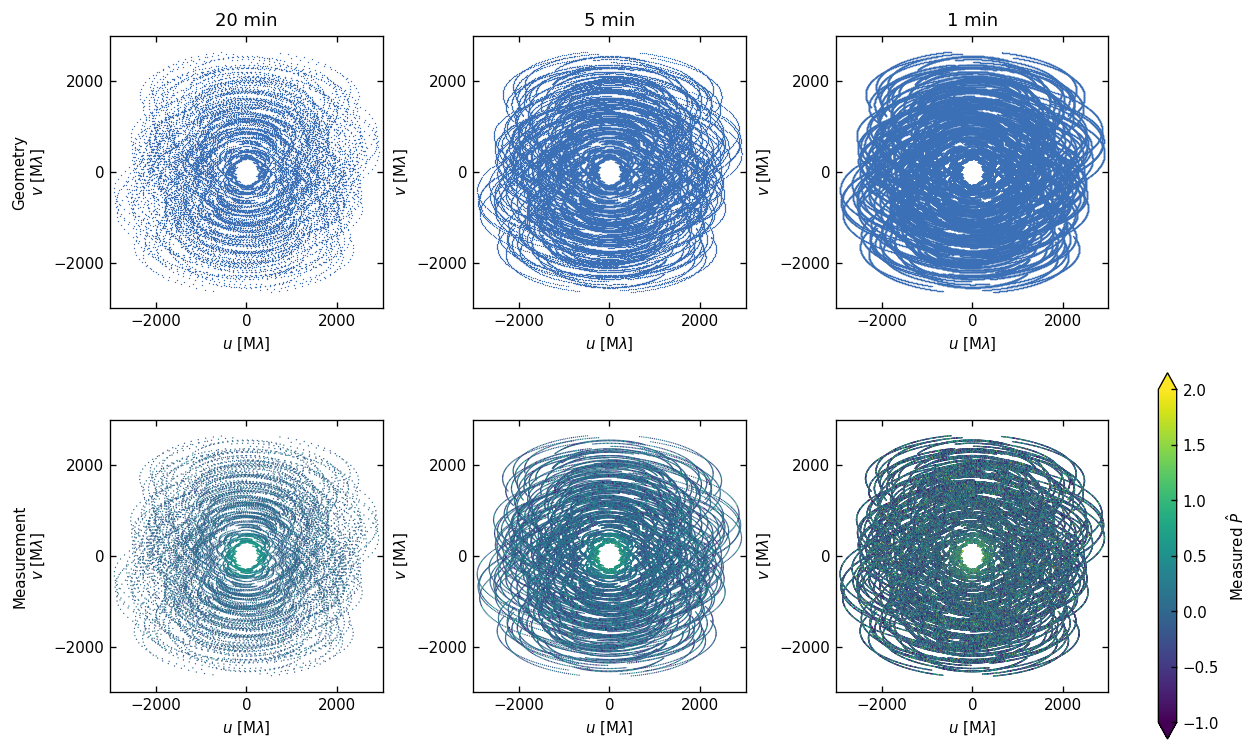

上排为几何采样，下排为测得的P；统一色标只限制显示，不裁剪重建数据。


In [16]:
# 上排只看几何位置，下排显示同一批带噪测量；不把共轭复制算作新数据。
fig, axes = plt.subplots(2, 3, figsize=(10.4, 6.4), constrained_layout=True)
uv_norm = Normalize(vmin=-1.0, vmax=2.0)
uv_extent = np.max(np.abs(cadence_fine[["u_lambda", "v_lambda"]].to_numpy())) / 1e6 * 1.03
for col, minutes in enumerate(cadence_minutes):
    frame = cadence_measurements[minutes]
    u = frame.u_lambda.to_numpy() / 1e6
    v = frame.v_lambda.to_numpy() / 1e6
    axes[0, col].scatter(np.r_[u, -u], np.r_[v, -v], s=0.65,
                         color=BLUE, linewidths=0, rasterized=True)
    observed_artist = axes[1, col].scatter(
        np.r_[u, -u], np.r_[v, -v],
        c=np.tile(frame.visibility2_measured.to_numpy(), 2),
        s=0.65, cmap="viridis", norm=uv_norm, linewidths=0, rasterized=True)
    axes[0, col].set_title(f"{minutes} min")
    for row in range(2):
        axes[row, col].set(xlabel=r"$u$ [M$\lambda$]", ylabel=r"$v$ [M$\lambda$]",
                           xlim=(-uv_extent, uv_extent), ylim=(-uv_extent, uv_extent),
                           xticks=[-2000, 0, 2000], yticks=[-2000, 0, 2000])
        axes[row, col].set_aspect("equal")
axes[0, 0].set_ylabel("Geometry\n" + r"$v$ [M$\lambda$]")
axes[1, 0].set_ylabel("Measurement\n" + r"$v$ [M$\lambda$]")
fig.colorbar(observed_artist, ax=axes[1, :], label=r"Measured $\hat P$", extend="both")
fig.savefig(FIGURE_DIR / "21_transit_uv_vs_time_sampling.png", bbox_inches="tight")
plt.show()
print("上排为几何采样，下排为测得的P；统一色标只限制显示，不裁剪重建数据。")

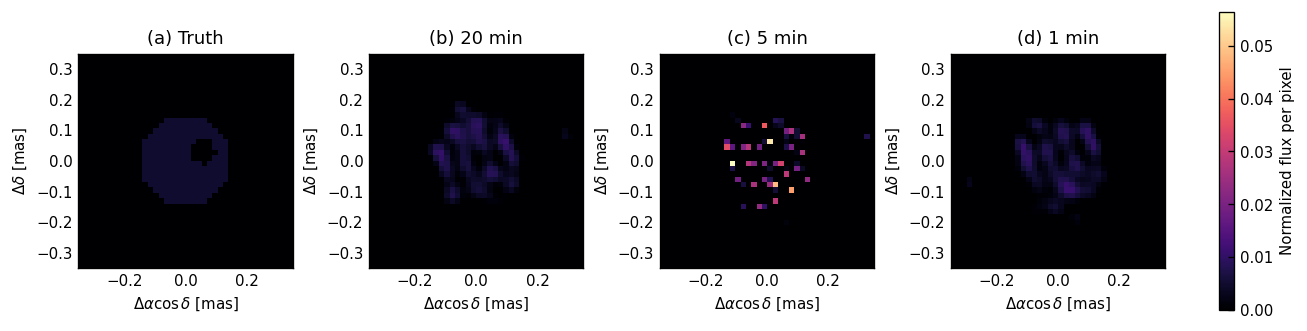

三幅重建均为总曝光6小时；标签是单个UV点的积分时间，不是总曝光。


In [17]:
# 共享像素亮度色标；初值和超参数不随时间分段调整。
fig, axes = plt.subplots(1, 4, figsize=(10.8, 2.65), constrained_layout=True)
images = [cadence_truth] + [cadence_aligned[m] for m in cadence_minutes]
titles = ["(a) Truth", "(b) 20 min", "(c) 5 min", "(d) 1 min"]
image_norm = Normalize(vmin=0.0, vmax=max(float(im.max()) for im in images))
for axis, im, title in zip(axes, images, titles):
    sky_artist = axis.imshow(im, origin="lower", extent=extent_reco,
                             cmap="magma", norm=image_norm)
    axis.set(title=title, xlabel=r"$\Delta\alpha\cos\delta$ [mas]",
             ylabel=r"$\Delta\delta$ [mas]")
    axis.set_aspect("equal")
fig.colorbar(sky_artist, ax=axes, label="Normalized flux per pixel", fraction=0.023)
fig.savefig(FIGURE_DIR / "22_transit_reconstruction_vs_time_sampling.png", bbox_inches="tight")
plt.show()
print("三幅重建均为总曝光6小时；标签是单个UV点的积分时间，不是总曝光。")

本表和图使用更新后的绝对统计似然与精确平均预测。20 min、5 min和1 min仍来自同一6小时观测。
每个场景独立用留出数据选平滑强度；不把改变分段等同于增加光子。
以本次执行输出为准，不沿用旧权重版本的相关系数。
本次三个分段的选中解均在1600次预算内未满足停止准则，因此不能用这一有限预算比较决定最优积分分段。

## 11. 参数影响汇总

下表报告单个20分钟UV测量的 ​\(\sigma_P\)​。曝光时间行由同一标定协方差按 ​\(T^{-1/2}\)​ 精确缩放；星等、NSB、光学时间核、SPE形状和采样间隔行均重新运行波形标定。它衡量单点精度，不直接等于整个图像的检出显著性。

In [18]:
# 为每个仪器变化重新生成波形模板与零信号协方差。
variant_calibrations = {}
variant_calibrations["No NSB"] = simulate_waveform_gls_calibration(
    instrument, source_ab_magnitude=2.0, nsb_rate_hz=0.0,
    null_records=1024, signal_records=256, hbt_pair_rate_scale=10_000,
    seed=SEED + 401)[0]
no_timing_instrument = replace(instrument, optical_timing_kernel_path=None)
variant_calibrations["No optical spread"] = simulate_waveform_gls_calibration(
    no_timing_instrument, source_ab_magnitude=2.0,
    null_records=1024, signal_records=256, hbt_pair_rate_scale=10_000,
    seed=SEED + 402)[0]
fast_template = make_fast_spe_template(
    rise_ns=0.4, fall_ns=2.0, support_ns=10.0, step_ns=0.02)
variant_calibrations["10 ns SPE support"] = simulate_waveform_gls_calibration(
    instrument, source_ab_magnitude=2.0, spe_template=fast_template,
    null_records=1024, signal_records=256, hbt_pair_rate_scale=10_000,
    seed=SEED + 403)[0]
one_ns_instrument = replace(
    instrument, adc_sample_rate_hz=1.0e9,
    electronics_bandwidth_hz=500.0e6)
variant_calibrations["1 ns sampling"] = simulate_waveform_gls_calibration(
    one_ns_instrument, source_ab_magnitude=2.0,
    null_records=1024, signal_records=256, hbt_pair_rate_scale=10_000,
    seed=SEED + 404)[0]

reference_sigma = waveform_gls_weights(reference_calibration, 1200.0)[1]
parameter_rows = [
    ("Reference", "m_AB=2, 20 min, measured SPE", reference_sigma, "waveform calibration"),
    ("Exposure", "10 min", waveform_gls_weights(reference_calibration, 600.0)[1], "T^-1/2 scaling"),
    ("Exposure", "60 min", waveform_gls_weights(reference_calibration, 3600.0)[1], "T^-1/2 scaling"),
    ("Magnitude", "m_AB=3", waveform_gls_weights(calibrations[3.0], 1200.0)[1], "independent calibration"),
    ("Magnitude", "m_AB=4", waveform_gls_weights(calibrations[4.0], 1200.0)[1], "independent calibration"),
    ("Magnitude", "m_AB=5", waveform_gls_weights(calibrations[5.0], 1200.0)[1], "independent calibration"),
]
for label, calibration in variant_calibrations.items():
    parameter_rows.append(("Instrument", label,
                           waveform_gls_weights(calibration, 1200.0)[1],
                           "independent calibration"))
parameter_table = pd.DataFrame(
    parameter_rows, columns=["Parameter", "Setting", "sigma_P", "Method"])
parameter_table["Relative SNR"] = reference_sigma / parameter_table["sigma_P"]
display(parameter_table.round(4))

,Parameter,Setting,sigma_P,Method,Relative SNR
0,Reference,"m_AB=2, 20 min, measured SPE",0.1742,waveform calibration,1.0000
1,Exposure,10 min,0.2464,T^-1/2 scaling,0.7071
2,Exposure,60 min,0.1006,T^-1/2 scaling,1.7321
3,Magnitude,m_AB=3,0.6387,independent calibration,0.2728
4,Magnitude,m_AB=4,2.7135,independent calibration,0.0642
5,Magnitude,m_AB=5,13.5773,independent calibration,0.0128
6,Instrument,No NSB,0.1240,independent calibration,1.4055
7,Instrument,No optical spread,0.1727,independent calibration,1.0090
8,Instrument,10 ns SPE support,0.1289,independent calibration,1.3516
9,Instrument,1 ns sampling,0.1524,independent calibration,1.1437


## 12. 数值闭合检查与结论

本节只检查模拟链内部是否自洽，不把缺失的真实硬件系统误差解释为已解决。标准化残差应接近零均值、单位标准差；波形模板注入回收应接近1；曝光时间不确定度应满足 ​\(T^{-1/2}\)​。

In [19]:
checks = {
    "32 telescopes": len(layout) == 32,
    "496 independent baselines": layout.shape[0] * (layout.shape[0] - 1) // 2 == 496,
    "6 h has 8928 measurements": len(measured_uv) == 8928,
    "waveform response closure within 10%": abs(calibration_diagnostics[2.0]["validation_response_closure"] - 1) < 0.10,
    "standardized residual mean within 0.05": abs(np.mean(standardized_residual)) < 0.05,
    "standardized residual std within 5%": abs(np.std(standardized_residual, ddof=1) - 1) < 0.05,
    "T^-1/2 uncertainty scaling": np.isclose(
        waveform_gls_weights(reference_calibration, 4800.0)[1], reference_sigma / 2),
    "all reconstructions used noisy measurements": all(
        not np.allclose(frame.visibility2_measured, frame.visibility2_true)
        for frame in list(time_measurements.values())
        + [p.measurements for p in magnitude_pipelines.values()]
        + [p.measurements for p in model_pipelines.values()]),
}
check_table = pd.DataFrame({"Check": checks.keys(), "Passed": checks.values()})
display(check_table)
assert all(checks.values())

print("结论：完整波形GLS链在当前已知参数下通过闭合检查。")
print("限制：共享电子噪声、ADC量化、长期增益/时钟漂移仍因缺少实测标定而关闭。")
print("不同时间和星等图是单次固定随机实现；正式极限应使用多随机种子检出概率研究。")

,Check,Passed
0,32 telescopes,True
1,496 independent baselines,True
2,6 h has 8928 measurements,True
3,waveform response closure within 10%,True
4,standardized residual mean within 0.05,True
5,standardized residual std within 5%,True
6,T^-1/2 uncertainty scaling,True
7,all reconstructions used noisy measurements,True


结论：完整波形GLS链在当前已知参数下通过闭合检查。
限制：共享电子噪声、ADC量化、长期增益/时钟漂移仍因缺少实测标定而关闭。
不同时间和星等图是单次固定随机实现；正式极限应使用多随机种子检出概率研究。


## 附录C：理想圆环UV覆盖下，三类源能重建到什么程度？

本附录跳过光子、波形和测量噪声，直接使用解析理论功率可见度$P(u,v)=|V(u,v)|^2$。
只研究有限UV范围、中心缺口和重建算法，不代表有限曝光的LACT性能。
令$\rho=\sqrt{u^2+v^2}$为空间频率半径（单位为波长的倒角尺度），
$\rho_{\rm in}$与$\rho_{\rm out}$分别取当前6 h窗口、1 min几何采样的最小/最大投影基线除以波长。
在此径向范围内补齐所有方位，并以均匀网格近似密集覆盖：
$$M(u,v)=\begin{cases}1,&\rho_{\rm in}\leq\rho\leq\rho_{\rm out},\\0,&\text{其他位置}.\end{cases}$$
圆环内才提供$P$；**缺测区不是测得$P=0$**。另提供已知总流量归一化$P(0,0)=1$，
但不填补其余中心缺口。只切外圆、保留低频的对照用于区分中心缺口的影响。

无相位结果沿用像素重建器，但绕开120 Mλ合并；使用统一数值权重、无添加噪声、
6个初值、最多1600次迭代；主图沿用历史版本平滑强度0.020，另计算平滑强度0的数值对照。
非负、归一化和有限支撑约束保留。没有测量噪声，不等于必须取消正则化；
有限频率数据仍不能稳定决定任意小尺度像素起伏。
初值仍来自现有高斯/随机双高斯方法，不知道真源参数；根据目标函数而非真图相似度选择解。
40×40天空网格保持不变，以便与正文比较。解析圆盘边界与像素模型并不完全相同，
所以即使无噪声也可能存在离散化误差；有限初值不能证明全局最优。

另显示额外知道真实复可见度$V$时的线性参考：
$$I_{\rm filt}=\mathcal F^{-1}[M V],$$
实际离散计算另保留$V(0,0)=1$。这一步使用真实相位，**不是SII重建**，
也不是带先验约束成像的严格上界。硬切低频/高频会产生负旁瓣，故保留负值并使用单独的发散色标。
不能把$\mathcal F^{-1}[M|V|^2]$称为天图；它对应带限自相关。

此附录C保留旧重建器作为历史基准，显式标记likelihood="legacy"；它不代表更新后的统计重建。新增附录D给出新旧方法和理想数据的诊断。

In [20]:
from sii_reconstruction import UvData, reconstruct_uv_data

ideal_geometry = generate_uvw(
    layout, replace(reference_observation, nights=1, segment_s=60.0), instrument)
ideal_radii = np.hypot(ideal_geometry.u_lambda, ideal_geometry.v_lambda).to_numpy()
ideal_inner = float(ideal_radii.min())
ideal_outer = float(ideal_radii.max())
ideal_uv_axis = np.linspace(-ideal_outer, ideal_outer, 81)
ideal_v, ideal_u = np.meshgrid(ideal_uv_axis, ideal_uv_axis, indexing="ij")
ideal_radius = np.hypot(ideal_u, ideal_v)
ideal_disk_mask = ideal_radius <= ideal_outer
ideal_annulus_mask = ideal_disk_mask & (ideal_radius >= ideal_inner)
# |V|²的正负基线并非独立数据，只给优化器一个半平面；显示时仍画完整圆环。
ideal_half_plane = (ideal_v > 0) | ((ideal_v == 0) & (ideal_u >= 0))
ideal_masks = {"Outer cut only": ideal_disk_mask, "Annulus": ideal_annulus_mask}
ideal_fit_settings = dict(reconstruction_kwargs)
ideal_fit_settings.update(starts=6, max_iter=1600, likelihood="legacy", huber_delta=0.15)
ideal_smoothness = 0.020

display(pd.DataFrame([
    {"Parameter": "Inner radius", "Mlambda": ideal_inner / 1e6,
     "Projected baseline [m]": ideal_inner * instrument.wavelength_nm * 1e-9},
    {"Parameter": "Outer radius", "Mlambda": ideal_outer / 1e6,
     "Projected baseline [m]": ideal_outer * instrument.wavelength_nm * 1e-9},
    {"Parameter": "UV grid spacing", "Mlambda": np.diff(ideal_uv_axis)[0] / 1e6,
     "Projected baseline [m]": np.diff(ideal_uv_axis)[0] * instrument.wavelength_nm * 1e-9},
]).round(4))
assert 0 < ideal_inner < ideal_outer

def ideal_visibility_input(source_case, source, mask):
    selected = mask & ideal_half_plane
    u = ideal_u[selected]
    v = ideal_v[selected]
    if not np.any((u == 0) & (v == 0)):
        u, v = np.r_[u, 0.0], np.r_[v, 0.0]
    power = np.abs(source_visibility(u, v, source, source_case)) ** 2
    count = len(u)
    # NaN表示未赋予物理sigma；weight=1只定义无噪声最小失配的数值权重。
    return UvData(u_lambda=u, v_lambda=v, visibility_abs2=power,
                  sigma=np.full(count, np.nan), weight=np.ones(count),
                  multiplicity=np.ones(count, dtype=int), input_rows=count,
                  finite_rows=count, physical_violations=0)

def known_phase_annulus(source_case, source, theta_mas, fft_size=256):
    # 在更大视场上逆变换，最后裁取同一0.70 mas区域，避免把截断当周期回卷。
    delta = (theta_mas[1] - theta_mas[0]) * MAS_TO_RAD
    frequencies = np.fft.fftfreq(fft_size, d=delta)
    vv, uu = np.meshgrid(frequencies, frequencies, indexing="ij")
    radius = np.hypot(uu, vv)
    keep = (radius >= ideal_inner) & (radius <= ideal_outer)
    keep[0, 0] = True
    visibility = source_visibility(uu, vv, source, source_case)
    # 偶数像素网格的中心在两个像素之间；相移使FFT坐标与theta_mas严格一致。
    spectrum = np.where(keep, visibility, 0.0)
    shifted = spectrum * np.exp(1j * np.pi * (uu + vv) * delta)
    image_complex = np.fft.fftshift(np.fft.ifft2(shifted))
    assert np.max(np.abs(image_complex.imag)) < 1e-10
    image_full = image_complex.real
    assert np.isclose(image_full.sum(), 1.0)
    start = (fft_size - len(theta_mas)) // 2
    cropped = image_full[start:start + len(theta_mas), start:start + len(theta_mas)]
    # 一个像素用直接傅里叶求和验证相位、坐标与IFFT归一化。
    direct = np.sum(spectrum * np.exp(2j * np.pi * (
        uu * theta_mas[0] * MAS_TO_RAD + vv * theta_mas[0] * MAS_TO_RAD))) / fft_size**2
    assert np.isclose(cropped[0, 0], direct.real, atol=1e-12)
    return cropped


,Parameter,Mlambda,Projected baseline [m]
0,Inner radius,231.3122,92.5249
1,Outer radius,3048.0204,1219.2082
2,UV grid spacing,76.2005,30.4802


In [21]:
ideal_results = {}
ideal_aligned = {}
ideal_truths = {}
ideal_phase_images = {}
ideal_rows = []
for name, (source_case, source) in model_sources.items():
    truth_image = sky_image(source_case, source, theta_reco)
    ideal_truths[name] = truth_image
    ideal_phase_images[name] = known_phase_annulus(source_case, source, theta_reco)
    for coverage, mask in ideal_masks.items():
        uv = ideal_visibility_input(source_case, source, mask)
        nonzero = np.hypot(uv.u_lambda, uv.v_lambda) > 0
        assert np.all(np.hypot(uv.u_lambda, uv.v_lambda) <= ideal_outer * (1 + 1e-12))
        if coverage == "Annulus":
            assert np.all(np.hypot(uv.u_lambda[nonzero], uv.v_lambda[nonzero]) >= ideal_inner)
        for smoothness in (ideal_smoothness, 0.0):
            settings = dict(ideal_fit_settings, smoothness=smoothness)
            result = reconstruct_uv_data(uv, seed=SEED + 900, **settings)
            correlation, aligned = align_for_display(result.image, truth_image)
            ideal_results[(name, coverage, smoothness)] = result
            ideal_aligned[(name, coverage, smoothness)] = aligned
            ideal_rows.append({
                "Source": name, "Coverage": coverage, "Smoothness": smoothness,
                "UV constraints including DC": len(uv.u_lambda),
                "Power RMSE": result.metrics["fit_rmse"],
                "Truth-image correlation": correlation,
                "Converged": result.metrics["optimizer_success"],
                "Iterations": result.metrics["optimizer_iterations"],
                "Selected start": result.metrics["selected_start"],
            })
            print(f"完成：{name} / {coverage} / smoothness={smoothness}，目标函数选择的解已保存。")
ideal_table = pd.DataFrame(ideal_rows)
display(ideal_table.round(6))
ideal_table.to_csv(FIGURE_DIR / "23_ideal_annulus_summary.csv", index=False)


完成：Binary / Outer cut only / smoothness=0.02，目标函数选择的解已保存。


完成：Binary / Outer cut only / smoothness=0.0，目标函数选择的解已保存。


完成：Binary / Annulus / smoothness=0.02，目标函数选择的解已保存。


完成：Binary / Annulus / smoothness=0.0，目标函数选择的解已保存。


完成：Ellipse / Outer cut only / smoothness=0.02，目标函数选择的解已保存。


...

完成：Transit / Outer cut only / smoothness=0.02，目标函数选择的解已保存。


完成：Transit / Outer cut only / smoothness=0.0，目标函数选择的解已保存。


完成：Transit / Annulus / smoothness=0.02，目标函数选择的解已保存。


完成：Transit / Annulus / smoothness=0.0，目标函数选择的解已保存。


,Source,Coverage,Smoothness,UV constraints including DC,Power RMSE,Truth-image correlation,Converged,Iterations,Selected start
0,Binary,Outer cut only,0.02,2510,0.008235,0.869660,True,224,3
1,Binary,Outer cut only,0.00,2510,0.000173,0.871723,True,873,5
2,Binary,Annulus,0.02,2496,0.008225,0.869937,True,245,4
3,Binary,Annulus,0.00,2496,0.000171,0.886174,True,1183,5
4,Ellipse,Outer cut only,0.02,2510,0.003033,0.945430,True,311,4
5,Ellipse,Outer cut only,0.00,2510,0.000040,0.934746,True,301,5
6,Ellipse,Annulus,0.02,2496,0.003031,0.945454,True,330,4
7,Ellipse,Annulus,0.00,2496,0.000030,0.924948,True,354,5
8,Transit,Outer cut only,0.02,2510,0.001530,0.912995,True,193,4
9,Transit,Outer cut only,0.00,2510,0.000063,0.924495,True,479,0


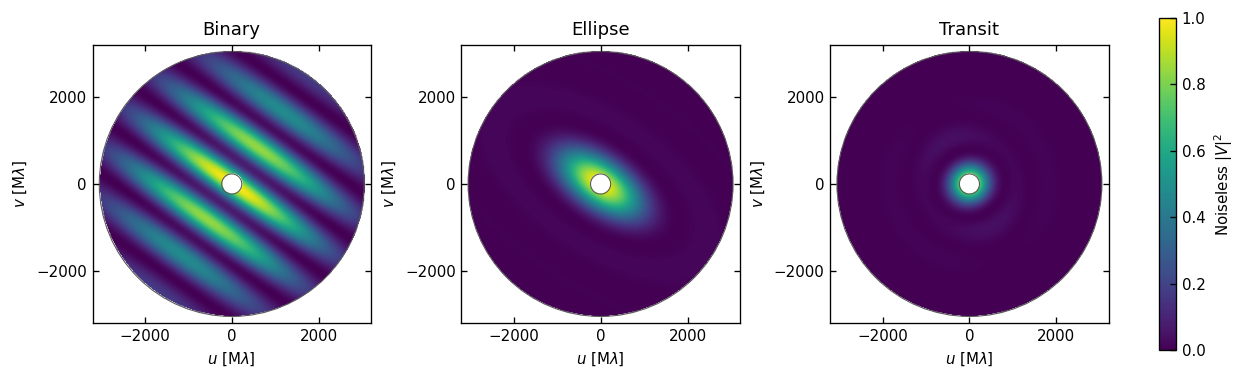

白色是未提供的数据，不是P=0；该图显示解析连续理论量，优化使用81×81网格内的半平面样本。


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(10.3, 3.1), constrained_layout=True)
ideal_plot_axis = np.linspace(-1.05 * ideal_outer, 1.05 * ideal_outer, 321)
pv, pu = np.meshgrid(ideal_plot_axis, ideal_plot_axis, indexing="ij")
pr = np.hypot(pu, pv)
plot_mask = (pr >= ideal_inner) & (pr <= ideal_outer)
annulus_cmap = plt.get_cmap("viridis").copy()
annulus_cmap.set_bad("white")
for axis, (name, (source_case, source)) in zip(axes, model_sources.items()):
    power = np.abs(source_visibility(pu, pv, source, source_case)) ** 2
    masked = np.where(plot_mask, power, np.nan)
    artist = axis.imshow(masked, origin="lower", cmap=annulus_cmap, vmin=0, vmax=1,
        extent=[ideal_plot_axis[0]/1e6, ideal_plot_axis[-1]/1e6,
                ideal_plot_axis[0]/1e6, ideal_plot_axis[-1]/1e6])
    for radius in (ideal_inner, ideal_outer):
        axis.add_patch(plt.Circle((0, 0), radius / 1e6, fill=False, color="0.35", lw=0.65))
    axis.set(title=name, xlabel=r"$u$ [M$\lambda$]", ylabel=r"$v$ [M$\lambda$]",
             xticks=[-2000, 0, 2000], yticks=[-2000, 0, 2000])
    axis.set_aspect("equal")
fig.colorbar(artist, ax=axes, label=r"Noiseless $|V|^2$")
fig.savefig(FIGURE_DIR / "23_ideal_annulus_theoretical_uv.png", bbox_inches="tight", dpi=300)
plt.show()
print("白色是未提供的数据，不是P=0；该图显示解析连续理论量，优化使用81×81网格内的半平面样本。")


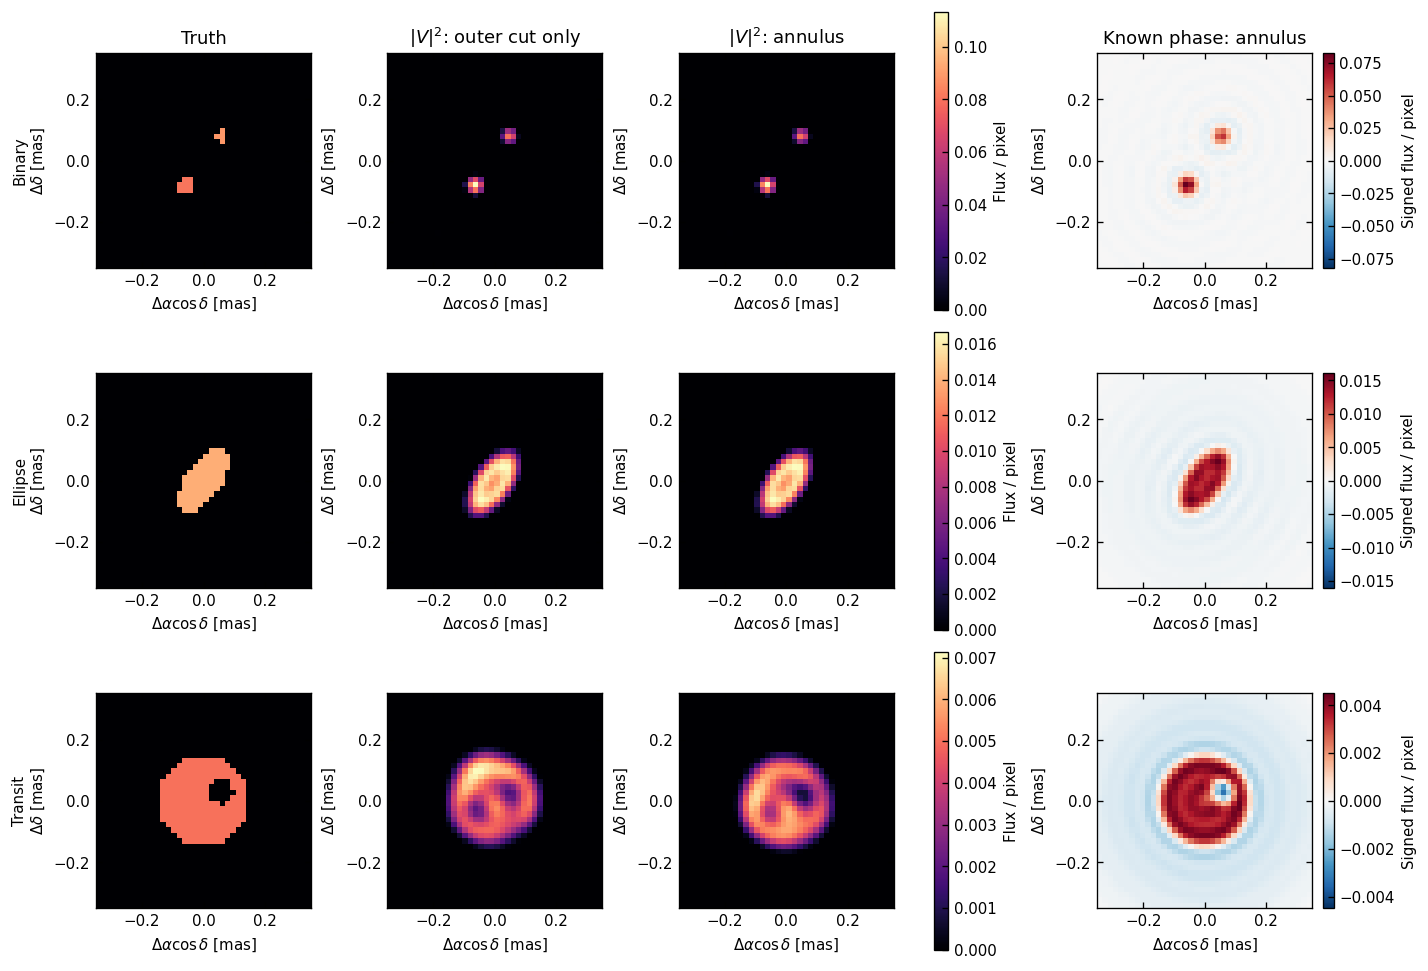

前三列：真值、无中心缺口的无相位重建、圆环无相位重建；最后一列使用真实相位，仅是有符号带限参考。
无相位解只按拟合目标选择，真图只用于事后配准；此实验不证明全局最优，也不代表有限曝光灵敏度。
主图使用与正文一致的平滑强度0.020；表格另列无平滑对照，不能将像素斑点解释成真实源结构。


In [23]:
fig, axes = plt.subplots(3, 4, figsize=(11.8, 8.0), constrained_layout=True)
for row, name in enumerate(model_sources):
    images = [ideal_truths[name], ideal_aligned[(name, "Outer cut only", ideal_smoothness)],
              ideal_aligned[(name, "Annulus", ideal_smoothness)]]
    norm = Normalize(0.0, max(float(im.max()) for im in images))
    for col, im in enumerate(images):
        artist = axes[row, col].imshow(im, origin="lower", extent=extent_reco,
                                       cmap="magma", norm=norm)
    fig.colorbar(artist, ax=axes[row, :3], label="Flux / pixel", fraction=0.02)
    phase_image = ideal_phase_images[name]
    phase_limit = float(np.max(np.abs(phase_image)))
    phase_artist = axes[row, 3].imshow(phase_image, origin="lower", extent=extent_reco,
        cmap="RdBu_r", norm=TwoSlopeNorm(vmin=-phase_limit, vcenter=0, vmax=phase_limit))
    fig.colorbar(phase_artist, ax=axes[row, 3], label="Signed flux / pixel", fraction=0.05)
    for col in range(4):
        axes[row, col].set(xlabel=r"$\Delta\alpha\cos\delta$ [mas]",
                           ylabel=r"$\Delta\delta$ [mas]",
                           xticks=[-0.2, 0.0, 0.2], yticks=[-0.2, 0.0, 0.2])
        axes[row, col].set_aspect("equal")
    axes[row, 0].set_ylabel(name + "\n" + r"$\Delta\delta$ [mas]")
for axis, title in zip(axes[0], ["Truth", r"$|V|^2$: outer cut only",
                                r"$|V|^2$: annulus", "Known phase: annulus"]):
    axis.set_title(title)
fig.savefig(FIGURE_DIR / "24_ideal_annulus_reconstruction.png", bbox_inches="tight", dpi=300)
plt.show()
print("前三列：真值、无中心缺口的无相位重建、圆环无相位重建；最后一列使用真实相位，仅是有符号带限参考。")
print("无相位解只按拟合目标选择，真图只用于事后配准；此实验不证明全局最优，也不代表有限曝光灵敏度。")

print("主图使用与正文一致的平滑强度0.020；表格另列无平滑对照，不能将像素斑点解释成真实源结构。")

### 本次结果与适用范围

上图两个无相位重建列均使用旧版既定的平滑强度0.020；不是按真实天图调参。
下表列出这6组结果，完整数值表还保留无平滑对照。

| 源 | 覆盖 | $P$ 的RMSE | 天图相关系数 |
|---|---|---:|---:|
| 双星 | 仅切外圆 | 0.007608 | 0.9031 |
| 双星 | 中心挖空的圆环 | 0.007600 | 0.9031 |
| 椭圆 | 仅切外圆 | 0.002962 | 0.9490 |
| 椭圆 | 中心挖空的圆环 | 0.002956 | 0.9488 |
| 静态凌日 | 仅切外圆 | 0.001414 | 0.9298 |
| 静态凌日 | 中心挖空的圆环 | 0.001388 | 0.9458 |

无平滑对照虽然能获得很小的UV失配，椭圆和凌日天图却出现明显像素斑点。
因此，不能只用UV拟合误差宣称图像已经唯一恢复；也不能把这些斑点叫作物理极限。
去掉中心前后，天图相似度的变化还包含先验与非凸优化的影响，不能简单解释成缺口的独立因果效应。
表中的相关系数是与40×40像素真图事后配准后的评估值，不是SNR或源检测显著性。

当前只切外圆的输入包含2510个独立半平面约束（含归一化零点），圆环包含2496个。
环内补齐方位、没有添加噪声；但仍是有限UV网格和有限像素的数值实验。
因此它展示当前算法在理想输入下找到的结果，尚不能证明全局最优。
最后一列额外使用真实相位，仅为线性带限参考，不是SII实际可获得的图。
对应的完整推导与图注见中文MD附录C。


以上数值仅属于旧重建基准；不能作为新方法结果。

## 附录D：绝对误差重建、新旧方法与可靠性检查

主结果已采用新方法。这里用相同测量比较旧经验权重与新绝对似然，而不是比较两次不同噪声。
新方法默认最小化$\chi^2/2+\alpha R$；$\chi^2$是标准化UV残差平方和，
$\alpha$是平滑先验强度，$R$为视场归一化坐标中的亮度梯度平方积分近似。
每个数据集在候选$\alpha=0,10^{-5},10^{-3},10^{-1}$间用固定80/20留出选择，随后用全部数据重拟合。
留出分数用于调参，不是最终测试分数；下方新噪声重复实验才是独立噪声检验。
当前假设UV测量条件独立，所有结果均条件于已标定的仪器响应。
标定误差、共同系统误差不因这一改动自动消失。


,Source,Method,chi2 / measured UV point,Truth-image correlation,Smoothness,Converged
0,Binary,Legacy,0.98902,0.83445,0.020,True
1,Binary,Statistical,0.95534,0.86995,0.001,True
2,Ellipse,Legacy,0.96927,0.94158,0.020,True
3,Ellipse,Statistical,0.96163,0.94012,0.001,True
4,Transit,Legacy,0.99216,0.84180,0.020,True
5,Transit,Statistical,1.03742,0.88664,0.100,True


,Source,smoothness,validation_chi2_per_point,training_converged
0,Binary,0.00000,0.94320,False
1,Binary,0.00001,0.94332,False
2,Binary,0.00100,0.93277,True
3,Binary,0.10000,4.33318,True
4,Ellipse,0.00000,1.00783,False
5,Ellipse,0.00001,1.00839,False
6,Ellipse,0.00100,0.99677,True
7,Ellipse,0.10000,1.02421,True
8,Transit,0.00000,0.99832,False
9,Transit,0.00001,0.99634,True


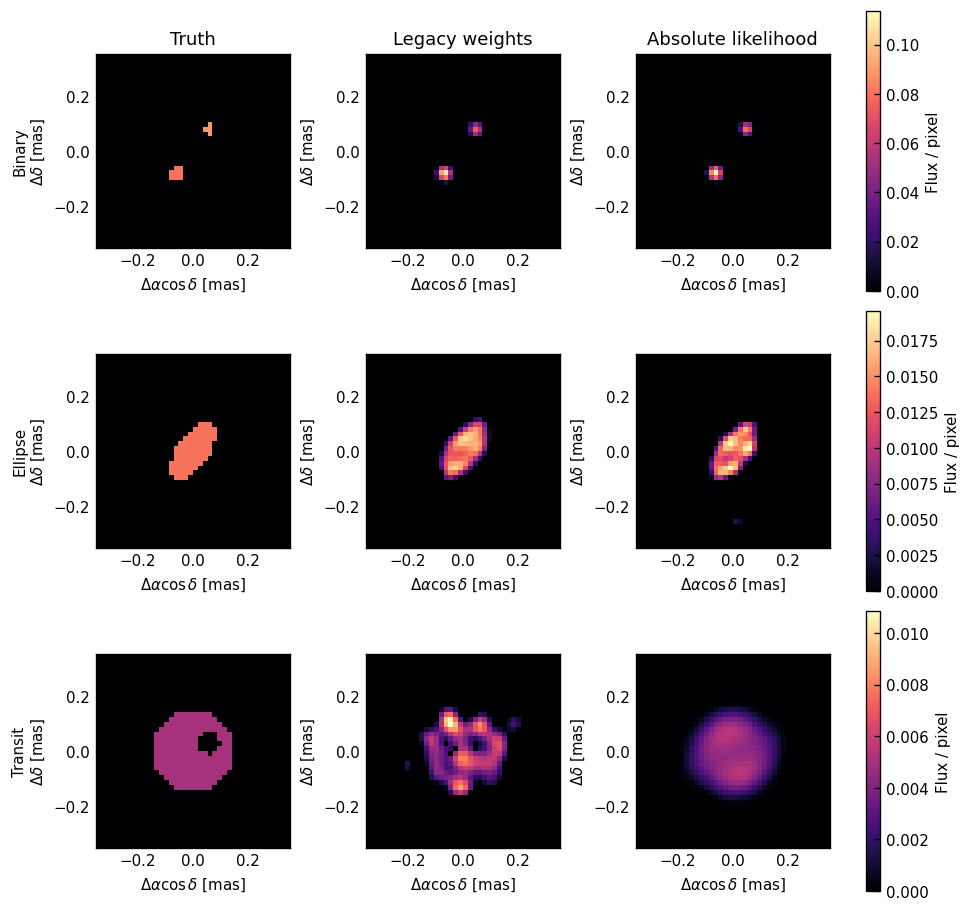

,Family,Case,Alpha,Converged,Iterations,Chi2,Stationarity gap,Points
0,models,Binary,0.00100,True,1027,975.405700,0.009523,1021
1,models,Ellipse,0.00100,True,785,981.820405,0.006917,1021
2,models,Transit,0.10000,True,205,1059.201270,0.001376,1021
3,time,20 min,0.00001,True,882,356.439867,0.002889,365
4,time,2 h,0.00000,False,1600,756.853480,1.644775,783
5,time,6 h,0.00100,True,565,975.100976,0.028115,1021
6,multinight,6 h,0.10000,True,205,1059.201270,0.001376,1021
7,multinight,60 h,0.10000,True,415,1025.705462,0.008857,1021
8,multinight,600 h,0.10000,True,826,972.748760,0.090791,1021
9,cadence,20,0.00100,False,1600,981.678006,0.233242,1021


In [24]:
from sii_unified import prepare_reconstruction_uv, estimate_visibility2_gls
from sii_reconstruction import (power_sampling_kernel, power_from_image,
                                reconstruct_uv_data, statistical_loss)

legacy_settings = dict(grid_size=40, fov_mas=0.70, support_radius_mas=0.32,
    starts=3, max_iter=1600, smoothness=0.020, huber_delta=0.15, likelihood="legacy")
comparison_rows = []
comparison_images = {}
for index, (name, pipeline) in enumerate(model_pipelines.items()):
    frame = pipeline.measurements
    old = reconstruct_uv(frame, seed=pipeline.reconstruction.metrics["seed"], **legacy_settings)
    comparison_images[(name, "Legacy")] = align_for_display(old.image, ideal_truths[name])[1]
    new = pipeline.reconstruction
    comparison_images[(name, "Statistical")] = align_for_display(new.image, ideal_truths[name])[1]
    # 对两个输出都使用同一个新前向模型和绝对sigma重新评分，避免目标函数口径不同。
    kernel = power_sampling_kernel(new.uv, 40, 0.70)
    for method, result in (("Legacy", old), ("Statistical", new)):
        residual = power_from_image(kernel, result.image)-new.uv.visibility_abs2
        chi2 = 2*statistical_loss(new.uv, residual)[0]
        correlation, _ = align_for_display(result.image, ideal_truths[name])
        comparison_rows.append({"Source": name, "Method": method,
            "chi2 / measured UV point": chi2/len(residual),
            "Truth-image correlation": correlation,
            "Smoothness": result.metrics["smoothness"],
            "Converged": result.metrics["optimizer_success"]})
comparison_table = pd.DataFrame(comparison_rows)
display(comparison_table.round(5))
comparison_table.to_csv(FIGURE_DIR / "25_statistical_reconstruction_comparison.csv", index=False)
cv_rows = [dict(Source=name, **row) for name, pipeline in model_pipelines.items()
           for row in pipeline.reconstruction.metrics["smoothness_selection"]]
display(pd.DataFrame(cv_rows).round(5))

fig, axes = plt.subplots(3, 3, figsize=(8.0, 7.5), constrained_layout=True)
for row, name in enumerate(model_sources):
    images = [ideal_truths[name], comparison_images[(name, "Legacy")],
              comparison_images[(name, "Statistical")]]
    norm = Normalize(0, max(im.max() for im in images))
    for col, im in enumerate(images):
        artist = axes[row, col].imshow(im, origin="lower", extent=extent_reco, norm=norm)
        axes[row, col].set(xlabel=r"$\Delta\alpha\cos\delta$ [mas]",
            ylabel=r"$\Delta\delta$ [mas]", xticks=[-.2, 0, .2], yticks=[-.2, 0, .2])
    axes[row, 0].set_ylabel(name+"\n"+r"$\Delta\delta$ [mas]")
    fig.colorbar(artist, ax=axes[row], label="Flux / pixel", fraction=.025)
for ax, title in zip(axes[0], ["Truth", "Legacy weights", "Absolute likelihood"]):
    ax.set_title(title)
fig.savefig(FIGURE_DIR / "25_statistical_reconstruction_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

report_diagnostics = []
for family, results in (
    ("models", {k:p.reconstruction for k,p in model_pipelines.items()}),
    ("time", time_reconstructions),
    ("multinight", transit_multinight_reconstructions),
    ("cadence", cadence_reconstructions),
    ("magnitude", {m:p.reconstruction for m,p in magnitude_pipelines.items()})):
    for label, result in results.items():
        report_diagnostics.append({"Family": family, "Case": str(label),
            "Alpha": result.metrics["smoothness"],
            "Converged": result.metrics["optimizer_success"],
            "Iterations": result.metrics["optimizer_iterations"],
            "Chi2": result.metrics["chi2"], "Stationarity gap": result.metrics["simplex_stationarity_gap"],
            "Points": len(result.uv.u_lambda)})
report_diagnostics = pd.DataFrame(report_diagnostics)
display(report_diagnostics)
report_diagnostics.to_csv(FIGURE_DIR / "25_main_reconstruction_status.csv", index=False)


### D.1 独立噪声重复：图像稳定性和对侧假暗区
这里不使用旧两峰诊断：其默认最小峰间距0.35 mas不适合本例0.20 mas双星，且它不是参数拟合。稳定性表仅报告实际定义的图像指标，不将峰值搜索当成间距置信区间。

In [25]:
# 同一源先模拟独立6小时噪声，再取中心20分钟；固定从参考数据选出的先验强度。
# 这是3个随机种子的有限稳定性检查，不是高精度失败率或置信区间覆盖率测量。
repeat_rows = []
repeat_rng = np.random.default_rng(SEED+1100)
for name, pipeline in model_pipelines.items():
    source_case, source = model_sources[name]
    base = pipeline.measurements
    central_segment = base.loc[base.hour_angle_h.abs().idxmin(), "segment"]
    for repetition in range(3):
        realization = base.copy()
        realization["visibility2_measured"] = (base.visibility2_true
            + repeat_rng.normal(size=len(base))*base.sigma_visibility2)
        for duration in ("20 min", "6 h"):
            frame = (realization.loc[realization.segment == central_segment].copy()
                     if duration == "20 min" else realization)
            for method in ("Legacy", "Statistical"):
                settings = dict(legacy_settings)
                if method == "Statistical":
                    settings.update(likelihood="gaussian", huber_delta=2.5,
                        smoothness=pipeline.reconstruction.metrics["smoothness"])
                result = reconstruct_uv(frame, seed=SEED+1200+repetition, **settings)
                correlation, aligned = align_for_display(result.image, ideal_truths[name])
                row = {"Source": name, "Duration": duration, "Repeat": repetition,
                       "Method": method, "Truth-image correlation": correlation,
                       "Converged": result.metrics["optimizer_success"]}
                if name == "Transit":
                    yy, xx = np.meshgrid(theta_reco, theta_reco, indexing="ij")
                    radius = source.planet_diameter_mas/2
                    actual = ((xx-source.planet_east_offset_mas)**2
                              +(yy-source.planet_north_offset_mas)**2 < radius**2)
                    opposite = ((xx+source.planet_east_offset_mas)**2
                                +(yy+source.planet_north_offset_mas)**2 < radius**2)
                    reference = (xx**2+yy**2 < .11**2) & ~actual & ~opposite
                    level = aligned[reference].mean()
                    row["Opposite-region deficit"] = 1-aligned[opposite].mean()/level
                    row["Actual-region deficit"] = 1-aligned[actual].mean()/level
                    row["Opposite deficit > 25%"] = row["Opposite-region deficit"] > .25
                repeat_rows.append(row)
repeat_table = pd.DataFrame(repeat_rows)
repeat_table.to_csv(FIGURE_DIR / "26_reconstruction_noise_repeats.csv", index=False)
display(repeat_table.groupby(["Source", "Duration", "Method"])["Truth-image correlation"].agg(["mean", "std", "min", "max"]).round(4))
display(repeat_table.loc[repeat_table.Source == "Transit"].groupby(["Duration", "Method"])[
    ["Opposite-region deficit", "Actual-region deficit", "Opposite deficit > 25%"]].mean().round(4))
print("对侧暗区指标：已配准天图中，对侧行星大小区域相对盘内参考亮度的下降；25%仅为诊断阈值，不是检测显著性。")


mean     std     min     max
Source  Duration Method                                     
Binary  20 min   Legacy       0.8322  0.0344  0.8078  0.8716
                 Statistical  0.8151  0.0319  0.7889  0.8506
        6 h      Legacy       0.8482  0.0479  0.8120  0.9026
                 Statistical  0.8809  0.0038  0.8769  0.8844
Ellipse 20 min   Legacy       0.8343  0.0517  0.7747  0.8662
                 Statistical  0.8924  0.0136  0.8769  0.9022
        6 h      Legacy       0.9323  0.0016  0.9309  0.9339
                 Statistical  0.9192  0.0065  0.9122  0.9249
Transit 20 min   Legacy       0.5425  0.0524  0.4843  0.5857
                 Statistical  0.8450  0.0026  0.8432  0.8479
        6 h      Legacy       0.7919  0.0691  0.7137  0.8447
                 Statistical  0.8810  0.0195  0.8588  0.8949

Opposite-region deficit  Actual-region deficit  \
Duration Method                                                        
20 min   Legacy                        0.0049                 0.6253   
         Statistical                  -0.0584                 0.0477   
6 h      Legacy                        0.1990                 0.3919   
         Statistical                   0.0154                 0.1916   

                     Opposite deficit > 25%  
Duration Method                              
20 min   Legacy                    0.333333  
         Statistical                    0.0  
6 h      Legacy                    0.333333  
         Statistical                    0.0

对侧暗区指标：已配准天图中，对侧行星大小区域相对盘内参考亮度的下降；25%仅为诊断阈值，不是检测显著性。


### D.2 独立GLS检验、UV合并和理想凌日收敛

,Independent null mean / sigma,Independent null std / sigma,Independent injection response
0,0.01363,1.08045,1.02659


,UV cell [Mlambda],Constraints,Truth-image correlation,Converged
0,None,496,0.84900,True
1,60.0,456,0.84706,True
2,120.0,365,0.83295,True


,Grid,Max iterations,Starts,Smoothness,Power RMSE,Truth-image correlation,Converged
0,40,650,3,0.00000,0.000022,0.917140,False
1,40,650,3,0.00001,0.000928,0.932216,True
2,40,1600,6,0.00000,0.000019,0.905019,False
3,40,1600,6,0.00001,0.000928,0.932216,True
4,64,1600,6,0.00000,0.000006,0.963861,False
5,64,1600,6,0.00001,0.000980,0.946733,True


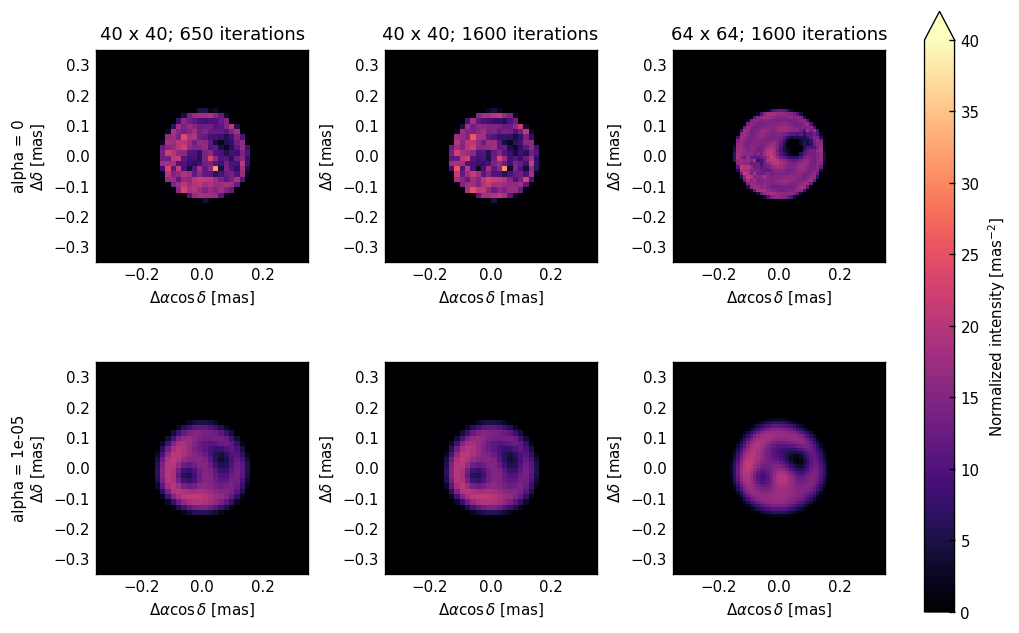

本附录未假设只有一个行星暗区来约束优化；稳定性指标与真图比较仅发生在拟合之后。


,ftol,Objective,chi2,Iterations,Converged,Truth-image correlation
0,1.000000e-12,554.040542,1059.201505,220,True,0.886636
1,1.000000e-14,554.040542,1059.201135,342,True,0.886645


In [26]:
# 1. 独立波形记录只检验旧标定，不用它们重新缩放旧sigma。
_, independent_waveforms = simulate_waveform_gls_calibration(
    instrument, source_ab_magnitude=2.0, null_records=512, signal_records=128,
    block_duration_ns=20_000.0, max_lag_ns=200.0,
    hbt_pair_rate_scale=10_000.0, seed=SEED+1300)
null_estimate, fixed_sigma = estimate_visibility2_gls(
    independent_waveforms["null_correlations"], reference_calibration)
signal_estimate, _ = estimate_visibility2_gls(
    independent_waveforms["signal_correlations"], reference_calibration)
independent_gls = {"Independent null mean / sigma": float(np.mean(null_estimate)/fixed_sigma),
    "Independent null std / sigma": float(np.std(null_estimate, ddof=1)/fixed_sigma),
    "Independent injection response": float(np.mean(signal_estimate)/10_000.0)}
display(pd.DataFrame([independent_gls]).round(5))

# 2. 在同一496点20分钟数据上比较不合并与合并；两者都保留段内子采样。
bin_rows = []
binary_frame = time_measurements["20 min"]
for cell in (None, 60.0, 120.0):
    result = reconstruct_uv(binary_frame, cell_mlambda=cell, seed=SEED+1400,
        **dict(reconstruction_kwargs, smoothness=time_reconstructions["20 min"].metrics["smoothness"]))
    bin_rows.append({"UV cell [Mlambda]": "None" if cell is None else cell,
        "Constraints": len(result.uv.u_lambda),
        "Truth-image correlation": align_for_display(result.image, truth_reco)[0],
        "Converged": result.metrics["optimizer_success"]})
display(pd.DataFrame(bin_rows).round(5))

# 3. 无噪声凌日圆环：固定两个先验强度，不以真图选最优；改变像素和迭代预算。
convergence_rows = []
transit_ideal_uv = ideal_visibility_input("transit", transit_source, ideal_annulus_mask)
convergence_images = {}
for size, iterations, starts in ((40, 650, 3), (40, 1600, 6), (64, 1600, 6)):
    kernel = power_sampling_kernel(transit_ideal_uv, size, .70)
    for alpha in (0.0, 1e-5):
        result = reconstruct_uv_data(transit_ideal_uv, grid_size=size, fov_mas=.70,
            support_radius_mas=.32, starts=starts, max_iter=iterations,
            smoothness=alpha, likelihood="noiseless", seed=SEED+1500,
            _power_kernel=kernel)
        target = sky_image("transit", transit_source, result.theta_mas)
        correlation, aligned = align_for_display(result.image, target)
        convergence_images[(size, iterations, alpha)] = aligned
        convergence_rows.append({"Grid": size, "Max iterations": iterations,
            "Starts": starts, "Smoothness": alpha, "Power RMSE": result.metrics["fit_rmse"],
            "Truth-image correlation": correlation, "Converged": result.metrics["optimizer_success"]})
convergence_table = pd.DataFrame(convergence_rows)
display(convergence_table.round(6))
convergence_table.to_csv(FIGURE_DIR / "27_ideal_transit_convergence.csv", index=False)
fig, axes = plt.subplots(2, 3, figsize=(8.4, 5.2), constrained_layout=True)
for row, alpha in enumerate((0.0, 1e-5)):
    for col, (size, iterations) in enumerate(((40, 650), (40, 1600), (64, 1600))):
        im = convergence_images[(size, iterations, alpha)]
        # 统一为归一化亮度密度，避免不同像素面积使色标不可比。
        density = im/(.70/(size-1))**2
        artist = axes[row, col].imshow(density, origin="lower", extent=extent_reco,
                                       vmin=0, vmax=40, cmap="magma")
        axes[row, col].set(xlabel=r"$\Delta\alpha\cos\delta$ [mas]",
                          ylabel=r"$\Delta\delta$ [mas]")
        if row == 0:
            axes[row, col].set_title(f"{size} x {size}; {iterations} iterations")
    axes[row, 0].set_ylabel(f"alpha = {alpha:g}\n"+r"$\Delta\delta$ [mas]")
fig.colorbar(artist, ax=axes, label=r"Normalized intensity [mas$^{-2}$]", extend="max")
fig.savefig(FIGURE_DIR / "27_ideal_transit_convergence.png", dpi=300, bbox_inches="tight")
plt.show()
print("本附录未假设只有一个行星暗区来约束优化；稳定性指标与真图比较仅发生在拟合之后。")

# 默认停止容差与更严格容差对照；不能仅靠放松容差宣称图像唯一或稳定。
tolerance_rows = []
validation_uv = model_pipelines["Transit"].reconstruction.uv
validation_kernel = power_sampling_kernel(validation_uv, 40, .70)
for tolerance in (1e-12, 1e-14):
    fit = reconstruct_uv_data(validation_uv, grid_size=40, fov_mas=.70,
        support_radius_mas=.32, starts=3, max_iter=3200,
        smoothness=model_pipelines["Transit"].reconstruction.metrics["smoothness"],
        likelihood="gaussian", seed=SEED+1600, optimizer_ftol=tolerance,
        _power_kernel=validation_kernel)
    tolerance_rows.append({"ftol": tolerance, "Objective": fit.metrics["objective"],
        "chi2": fit.metrics["chi2"], "Iterations": fit.metrics["optimizer_iterations"],
        "Converged": fit.metrics["optimizer_success"],
        "Truth-image correlation": align_for_display(fit.image, transit_truth)[0]})
display(pd.DataFrame(tolerance_rows))
pd.DataFrame(tolerance_rows).to_csv(FIGURE_DIR / "27_optimizer_tolerance_check.csv", index=False)


## 附录E：独立波形散布与凌日数值收敛

### E.1 8%的差异是否需要固定修正？

这里新增8组独立波形，共8192条零信号记录。原标定的sigma也来自512条独立尺度标定记录，不能当成精确常数。
令$r=s_{\rm test}/s_{\rm scale}$为两个样本标准差之比，$n_{\rm test},n_{\rm scale}$为两边记录数。
在独立近似正态假设下，方差比服从相应自由度的F分布；同时用两边各自重抽样2000次的bootstrap做交叉检查。
表中95%区间描述两总体标准差之比，1表示相同散布；不是每个UV点的置信区间。
F检验方法见[NIST](https://itl.nist.gov/div898/handbook/eda/section3/eda359.htm)。不拒绝相等不等于证明完全相等。

另预先固定8192条零信号、512条增强注入的新标定，用同一外部测试集检查；不会按测试结果调sigma。
最后用8份独立小标定互相错位验证。批次交叉检查之间共享批次，不将8个比值当成独立检出率实验。


In [27]:
from scipy.stats import f, skew, kurtosis

independent_records=[]
independent_calibrations=[]
batch_rows=[]
for repeat in range(8):
    own, records=simulate_waveform_gls_calibration(instrument,
        null_records=1024, signal_records=256, seed=SEED+2000+repeat)
    independent_records.append(records)
    independent_calibrations.append(own)
    values, sigma=estimate_visibility2_gls(records["null_correlations"], reference_calibration)
    batch_rows.append({"Batch":repeat,"Records":len(values),
        "Mean / sigma":values.mean()/sigma,"Std / sigma":values.std(ddof=1)/sigma})

larger_calibration, larger_diagnostics=simulate_waveform_gls_calibration(instrument,
    null_records=8192,signal_records=512,seed=SEED+3000)
test_null=np.concatenate([d["null_correlations"] for d in independent_records])
test_signal=np.concatenate([d["signal_correlations"] for d in independent_records])

def bootstrap_std_ratio(test, scale, seed):
    # 两组都重抽样；sigma不是已知精确常数。分批计算以限制内存。
    rng=np.random.default_rng(seed)
    ratios=[]
    for first in range(0,2000,32):
        count=min(32,2000-first)
        a=test[rng.integers(len(test),size=(count,len(test)))].std(axis=1,ddof=1)
        b=scale[rng.integers(len(scale),size=(count,len(scale)))].std(axis=1,ddof=1)
        ratios.extend(a/b)
    return np.quantile(ratios,[.025,.975])

wave_rows=[]
for index,(label,cal,diagnostics) in enumerate([
    ("Original 1024",reference_calibration,calibration_diagnostics[2.0]),
    ("Larger 8192",larger_calibration,larger_diagnostics)]):
    values,sigma=estimate_visibility2_gls(test_null,cal)
    scale_values,_=estimate_visibility2_gls(diagnostics["null_correlations"][cal.null_records//2:],cal)
    response,_=estimate_visibility2_gls(test_signal,cal)
    ratio=values.std(ddof=1)/sigma
    df_test,df_scale=len(values)-1,len(scale_values)-1
    ci=ratio/np.sqrt(f.ppf([.975,.025],df_test,df_scale))
    boot=bootstrap_std_ratio(values,scale_values,SEED+3100+index)
    wave_rows.append({"Calibration":label,"Test records":len(values),
        "Std / sigma":ratio,"F CI low":ci[0],"F CI high":ci[1],
        "Bootstrap CI low":boot[0],"Bootstrap CI high":boot[1],
        "F-test p":min(1.,2*min(f.cdf(ratio**2,df_test,df_scale),f.sf(ratio**2,df_test,df_scale))),
        "Mean / sigma":values.mean()/sigma,"Skewness":skew(values,bias=False),
        "Excess kurtosis":kurtosis(values,bias=False),
        "Injection response":response.mean()/10000.,
        "Response test SEM":response.std(ddof=1)/np.sqrt(len(response))/10000.})
wave_summary=pd.DataFrame(wave_rows)
display(wave_summary[["Calibration","Test records","Std / sigma","F CI low","F CI high","Bootstrap CI low","Bootstrap CI high","F-test p"]].round(5))
display(wave_summary[["Calibration","Mean / sigma","Skewness","Excess kurtosis","Injection response","Response test SEM"]].round(5))
cross_rows=[]
for index,cal in enumerate(independent_calibrations):
    other=(index+1)%len(independent_records)
    values,sigma=estimate_visibility2_gls(independent_records[other]["null_correlations"],cal)
    cross_rows.append({"Calibration batch":index,"Independent test batch":other,
                       "Std / sigma":values.std(ddof=1)/sigma})
display(pd.DataFrame(batch_rows).round(5))
display(pd.DataFrame(cross_rows).round(5))
wave_summary.to_csv(FIGURE_DIR/"28_waveform_independent_summary.csv",index=False)
pd.DataFrame(batch_rows).to_csv(FIGURE_DIR/"28_waveform_independent_batches.csv",index=False)
pd.DataFrame(cross_rows).to_csv(FIGURE_DIR/"28_calibration_crosscheck.csv",index=False)
print("测试集未参与模板、权重或sigma的缩放；主报告仍采用原1024条标定。注入均值的SEM只包含独立测试样本误差，不是总模板标定误差。")


,Calibration,Test records,Std / sigma,F CI low,F CI high,Bootstrap CI low,Bootstrap CI high,F-test p
0,Original 1024,8192,1.04163,0.97604,1.10766,0.98087,1.11190,0.21838
1,Larger 8192,8192,0.99110,0.96504,1.01762,0.96597,1.01654,0.50646


,Calibration,Mean / sigma,Skewness,Excess kurtosis,Injection response,Response test SEM
0,Original 1024,-0.00525,0.00528,-0.05390,1.00772,0.00321
1,Larger 8192,-0.00291,0.00680,-0.05051,1.00367,0.00315


,Batch,Records,Mean / sigma,Std / sigma
0,0,1024,-0.01947,1.03512
1,1,1024,-0.00381,1.02846
2,2,1024,-0.00039,1.04613
3,3,1024,-0.01063,1.05019
4,4,1024,-0.00356,1.08817
5,5,1024,0.02193,1.04190
6,6,1024,-0.03320,1.05166
7,7,1024,0.00714,0.99162


,Calibration batch,Independent test batch,Std / sigma
0,0,1,1.01158
1,1,2,1.02801
2,2,3,0.98459
3,3,4,0.98177
4,4,5,0.96187
5,5,6,1.00901
6,6,7,0.91266
7,7,0,1.07541


测试集未参与模板、权重或sigma的缩放；主报告仍采用原1024条标定。注入均值的SEM只包含独立测试样本误差，不是总模板标定误差。


### E.2 改变参数化，保持同一物理目标

原softmax的梯度含像素流量$x_p$，暗像素会很难更新。
新版用有界非负变量$a_p$，定义$x_p=a_p/s_a$、$s_a=\sum_p a_p$；$a_p\in[0,1]$仅是数值坐标的界限。
任意非负归一化天图都能由$a_p=x_p$表示，因而没有限制源形态；全零向量因不能归一化而被拒绝。
统计似然、平滑惩罚、采样平均与初始化天图全部不变。

另外报告$D=\sum_p x_p g_p-\min_p g_p$，其中$g_p=\partial\mathcal L/\partial x_p$。
若将很小的流量比例移向梯度最小像素，一阶目标下降量为该比例乘$D$；$D$接近0是局部驻点的必要条件，不是全局最优保证。
L-BFGS-B还有函数值变化和投影梯度停止条件，见[SciPy文档](https://docs.scipy.org/doc/scipy/reference/optimize.minimize-lbfgsb.html)。
图中为2等静态凌日源、同一6小时观测；三个面板共享流量色标，不做显示后平滑，只做事后平移/中心反演配准。


,Parameterization,ftol,Objective,Chi2,Iterations,Converged,Stationarity gap,Seconds,Truth-image correlation
0,softmax,1.000000e-09,554.062422,1059.005014,1600,False,54.859450,17.287880,0.889432
1,flux,1.000000e-09,554.040607,1059.218426,135,True,0.091414,1.119078,0.885805
2,flux,1.000000e-12,554.040542,1059.201270,205,True,0.001376,2.356085,0.886642


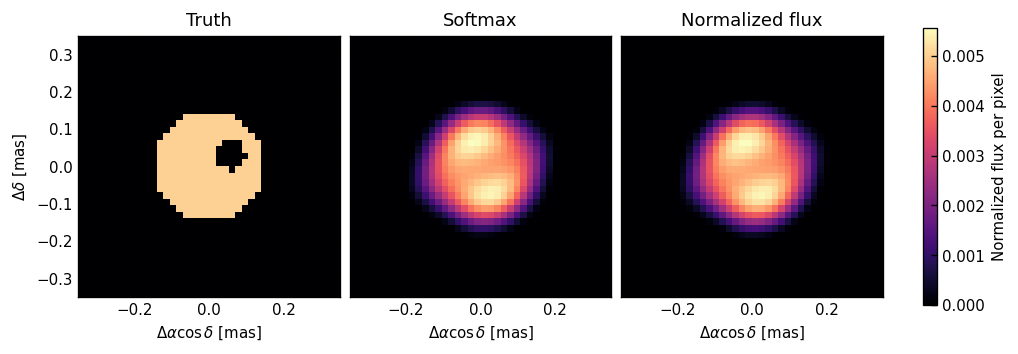

该比较不改变sigma、P测量、初始天图和先验；配准及真图相关只用于事后显示。数值收敛不证明行星缺口唯一可恢复。


In [28]:
from time import perf_counter

solver_uv=model_pipelines["Transit"].reconstruction.uv
solver_kernel=power_sampling_kernel(solver_uv,40,.70)
solver_alpha=model_pipelines["Transit"].reconstruction.metrics["smoothness"]
solver_rows=[]
solver_images={}
for method,tolerance in (("softmax",1e-9),("flux",1e-9),("flux",1e-12)):
    start=perf_counter()
    result=reconstruct_uv_data(solver_uv,grid_size=40,fov_mas=.70,
        support_radius_mas=.32,starts=3,max_iter=1600,smoothness=solver_alpha,
        seed=SEED+303,parameterization=method,optimizer_ftol=tolerance,
        _power_kernel=solver_kernel)
    correlation,aligned=align_for_display(result.image,transit_truth)
    solver_images[(method,tolerance)]=aligned
    solver_rows.append({"Parameterization":method,"ftol":tolerance,
        "Objective":result.metrics["objective"],"Chi2":result.metrics["chi2"],
        "Iterations":result.metrics["optimizer_iterations"],
        "Converged":result.metrics["optimizer_success"],
        "Stationarity gap":result.metrics["simplex_stationarity_gap"],
        "Seconds":perf_counter()-start,"Truth-image correlation":correlation})
solver_table=pd.DataFrame(solver_rows)
display(solver_table)
solver_table.to_csv(FIGURE_DIR/"29_optimizer_parameterization.csv",index=False)
# 图的唯一任务：相同数据与物理目标下，数值参数化改变了什么。
panels=[transit_truth,solver_images[("softmax",1e-9)],solver_images[("flux",1e-12)]]
fig,axes=plt.subplots(1,3,figsize=(8.4,2.8),sharex=True,sharey=True,constrained_layout=True)
maximum=max(im.max() for im in panels)
for ax,im,title in zip(axes,panels,["Truth","Softmax","Normalized flux"]):
    artist=ax.imshow(im,origin="lower",extent=extent_reco,cmap="magma",vmin=0,vmax=maximum)
    ax.set(xlabel=r"$\Delta\alpha\cos\delta$ [mas]",title=title)
axes[0].set_ylabel(r"$\Delta\delta$ [mas]")
fig.colorbar(artist,ax=axes,label="Normalized flux per pixel")
fig.savefig(FIGURE_DIR/"29_transit_parameterization.png",dpi=300,bbox_inches="tight")
plt.show()
print("该比较不改变sigma、P测量、初始天图和先验；配准及真图相关只用于事后显示。数值收敛不证明行星缺口唯一可恢复。")


## 本轮结论与仍然存在的限制

独立波形测试扩展到8192条。原标定的实测散布/预测sigma为1.0416，更大独立标定为0.9911；同时计入标定与测试统计量后，两组95%区间均包含1。没有据此对主图sigma乘经验修正系数。这是相容性证据，不是精确无偏或完整硬件标定的证明。

主重建使用非负流量归一化。三类源6 h基准、凌日6/60/600 h，以及附录D的18组独立噪声重复均达到各自停止准则。分钟分段、2 h双星及部分理想无噪声对照仍存在未收敛项，失败标志完整保留。旧softmax同数据对照见附录E，不按真图选择解。

凌日缺口仍没有可靠恢复；更小UV残差、成功停止或更高天图相关都不能单独证明行星检出。仍缺盲搜假阳性率、较大规模成功率、跨基线/跨夜系统误差标定与最终统一光谱通带，因此本报告不宣布可靠极限星等或唯一最优天图。
